# ENSO Feedback Diagnostics v2

Loads atmospheric model / reanalysis data for multiple cases and produces:

1. **1D PDFs** of Niño-region anomalies (VAR_X and VAR_Y) + 1D scatter/regression
2. **SST lag-correlation maps** at −6 / 0 / +6 months  (`DO_SST_LAG`)
3. **Cross-Pacific cross section** — VAR_XPACIFIC anomaly binned by NINO_X SST bins, lon × bin  (`DO_XPACIFIC`)
4. **Per-case 3D pressure-level** binned contour + PDF plots  (`DO_3D_PLOT`)
5. **Multi-case binned line** at one pressure level with SST-bias right axis
6. **2D lat-lon El Niño / La Niña composites** of VAR_LATLON  (`DO_LATLON`)
7. **Rossby Wave Source composites** at 200 hPa  (`DO_RWS`)
8. **PRECT + divergent wind + divergence** composites  (`DO_DIVWIND`)
9. **Z500 seasonal scatter** (spatial max/min) and **EOF PC1 scatter**  (`DO_Z500_SCATTER`)

In [30]:
import os
os.environ['DASK_TEMPORARY_DIRECTORY'] = '/glade/derecho/scratch/rneale/dask-temp'

import re
import importlib

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.transforms as mtransforms
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from scipy.stats import linregress
from scipy.interpolate import UnivariateSpline
from scipy.ndimage import gaussian_filter
from windspharm.xarray import VectorWind

import dask
from dask.distributed import Client
from dask_jobqueue import PBSCluster

import enso_feedbacks_utils as mypy

In [31]:
cluster = PBSCluster(
    account='P03010039',
    interface='ext',
    walltime='12:00:00',
    queue='main',
    cores=4,
    memory='32GB',
    processes=4,
    local_directory='/glade/derecho/scratch/rneale/dask-temp',
    log_directory='/glade/derecho/scratch/rneale/dask-logs',
    job_script_prologue=[
        'mkdir -p /glade/derecho/scratch/rneale/dask-temp',
        'mkdir -p /glade/derecho/scratch/rneale/dask-logs',
    ],
)
cluster.scale(jobs=32)
client = Client(cluster)
client

/glade/work/rneale/conda-envs/neale_vproc2/lib/python3.14/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 40931 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: /node/crhtc66.hpc.ucar.edu/54843/proxy/40931/status,
Dashboard: /node/crhtc66.hpc.ucar.edu/54843/proxy/40931/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.174:40529,Workers: 0
Dashboard: /node/crhtc66.hpc.ucar.edu/54843/proxy/40931/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [50]:
# ════════════════════════════════════════════════════════════════════
#  ALL USER OPTIONS
# ════════════════════════════════════════════════════════════════════

# ── Output ───────────────────────────────────────────────────────────────────
DIR_FIG    = '/glade/u/home/rneale/python/python-figs/papers/ENSO_vprocs_fbacks/'
FIG_PREFIX = 'new_code'   # prepended to all saved filenames ('' for none)

# ── Cases ───────────────────────────────────────────────────────────────────
LOOP_NCASES = 7   # how many entries below to run (slice from top)
CASE_TYPES  = ['OBS', 'OBS', 'CESM2', 'CESM1', 'E3SMv2', 'E3SMv3', 'CESM3']
CASE_NAMES  = [
    ['ERA5', 'ERA5'],
    ['MERRA2', 'MERRA2'],
    'b.e21.BHISTcmip6.f09_g17.LE2-1001.001',
    'b.e11.B20TRC5CNBDRD.f09_g16.001',
    'v2.FV1.historical_0101',
    'v3.LR.historical.en00',
    'b.e30_alpha08b.BHISTC_LTso.ne30_t232_wgx3.315',
]
CASE_YSTART = [1980, 1980, 1920, 1920, 1920, 1920, 1920]
CASE_YEND   = [2023, 2023, 2005, 2005, 2005, 2005, 2005]

# ── CESM3 explicit ensemble list ─────────────────────────────────────────────────────
CESM3_CASES = [
    'b.e30_alpha08b.BHISTC_LTso.ne30_t232_wgx3.315',
    'b.e30_alpha08b.BHISTC_LTso.ne30_t232_wgx3.316',
]

# ── Ensemble members per case (0 = single representative run) ───────────────────
N_MEMBERS  = [0, 0, 1, 1, 1, 1, len(CESM3_CASES)]
ENS_KWARGS = [{}, {}, {}, {}, {'e3sm_step': 10}, {}, {}]

# ── Season ───────────────────────────────────────────────────────────────────
SEASON     = 'NDJFM'
GET_MONTHS = [11, 12, 1, 2, 3]

# ── Niño regions ────────────────────────────────────────────────────────────────
NINO_X = 'nino34'
NINO_Y = 'nino4'

# ── Variables ───────────────────────────────────────────────────────────────────
VAR_X      = 'TS'    ; UNITS_X   = 'K'
VAR_Y      = 'PRECT' ; UNITS_Y   = 'mm/day'
VAR_3D     = 'OMEGA' ; UNITS_3D  = 'mb/hr' ; XLIM_PDF = [-1, 1] ; CRANGE_3D = [-2., 2.]
VAR_LATLON = 'Z3'    ; PLEV_LATLON = 500   ; UNITS_LL  = 'm'
PREGION    = 'TropPac'

# ── Analysis switches ───────────────────────────────────────────────────────────
DO_1D_PLOT      = True
DO_SST_LAG      = True
DO_XPACIFIC     = True
DO_3D_PLOT      = False
DO_LATLON       = False
DO_RWS          = False
DO_DIVWIND      = False
DO_Z500_SCATTER = False

# ── Smoothing ───────────────────────────────────────────────────────────────────
KDE_BW           = 0.3
DIV_SMOOTH_SIGMA = 1.5
RWS_SMOOTH_SIGMA = 1.5

# ── Z500 scatter region ─────────────────────────────────────────────────────────────
Z500_REGION = 'Boreal'

# ── Binned-line pressure level ───────────────────────────────────────────────────────
BINNED_PLEV       = 200.   # hPa; set None to use vertical mean
BINNED_PLEV_RANGE = None   # e.g. [200., 800.] — used only when BINNED_PLEV=None

# ── Cross-Pacific cross section ──────────────────────────────────────────────────────
VAR_XPACIFIC   = 'PRECT'   # variable to bin and plot across Pacific (as anomalies)
UNITS_XPACIFIC = 'mm/day'
XPACIFIC_LAT_S = -5.    # southern latitude bound for zonal averaging
XPACIFIC_LAT_N =  5.    # northern latitude bound for zonal averaging
CRANGE_XPAC    = [-8., 8.]

# ── Data I/O flags ───────────────────────────────────────────────────────────────
READ_ALL_HIST = False
WRITE_TS_FILE = False
READ_TS_FILE  = False

In [51]:
importlib.reload(mypy)

# ── Derived variable names ────────────────────────────────────────────────────────
_var_no_num  = re.sub(r'\d+', '', VAR_LATLON)
VAR_LATLON_2D = f'{_var_no_num}{int(PLEV_LATLON)}'   # e.g. 'Z500'

# ── Figure helper ─────────────────────────────────────────────────────────────
def fig_path(stem):
    pref = FIG_PREFIX + '_' if FIG_PREFIX else ''
    return os.path.join(DIR_FIG, pref + stem + '.png')

# ── Figure defaults ────────────────────────────────────────────────────────────
FSCALE = 1.0
FIGXY  = 12
plt.rcdefaults()
plt.rcParams.update({'font.size': 18 * FSCALE})

# ── Case styles ───────────────────────────────────────────────────────────────
COLORS, MARKERS, DISPLAY_NAMES = mypy.build_case_styles(
    CASE_NAMES, CASE_TYPES, LOOP_NCASES)

# ── Axis domains ────────────────────────────────────────────────────────────────
XMIN, XMAX, X_AVALS = mypy.fig_domains(VAR_X)
YMIN, YMAX, Y_AVALS = mypy.fig_domains(VAR_Y)

# ── Bin edges for 3D binned analysis ───────────────────────────────────────────
N_BINS      = 20
DLEV_BIN    = (XMAX - XMIN) / N_BINS
BIN_EDGES   = np.arange(XMIN, XMAX + DLEV_BIN, DLEV_BIN)
BIN_CENTERS = 0.5 * (BIN_EDGES[:-1] + BIN_EDGES[1:])

# ── Projection for lat-lon plots ──────────────────────────────────────────────
CCRS_PREG = (ccrs.Robinson(central_longitude=180.)
             if PREGION == 'Global' else ccrs.PlateCarree(central_longitude=180.))

# KDE bandwidth: precipitation variables benefit from a narrower bandwidth
_PREC_VARS = {'PRECT', 'PRECC', 'PRECL', 'PRECST', 'PRECS'}
KDE_BW_X = 0.25 if VAR_X in _PREC_VARS else KDE_BW
KDE_BW_Y = 0.25 if VAR_Y in _PREC_VARS else KDE_BW

print(f'VAR_X={VAR_X}  VAR_Y={VAR_Y}  VAR_3D={VAR_3D}  VAR_LATLON={VAR_LATLON_2D}')
print(f'Season={SEASON}  Nino-X={NINO_X}  Nino-Y={NINO_Y}')
print(f'Cases ({LOOP_NCASES}): {DISPLAY_NAMES}')

VAR_X=TS  VAR_Y=PRECT  VAR_3D=OMEGA  VAR_LATLON=Z500
Season=NDJFM  Nino-X=nino34  Nino-Y=nino4
Cases (7): ['ERA5', 'MERRA2', 'CESM2', 'CESM1', 'E3SMv2', 'E3SMv3', 'CESM3']


In [52]:
# Reference variability contour levels — auto-set from first case, reused for all
_slevels_ref = None
_swidths_ref = None

cases_data = []

for icase in range(LOOP_NCASES):
    cname     = CASE_NAMES[icase]
    ctype     = mypy.infer_ctype(cname)
    case_type = CASE_TYPES[icase]
    fcname    = cname[0] if isinstance(cname, list) else cname
    cnames    = cname if isinstance(cname, list) else [cname]
    yr0       = CASE_YSTART[icase]
    yr1       = CASE_YEND[icase]
    label     = DISPLAY_NAMES[icase]
    color     = COLORS[icase]
    marker    = MARKERS[icase]
    lstyle    = '-.' if icase == 1 else '-'

    print(f'\n+++ [{icase+1}/{LOOP_NCASES}] {label} ({yr0}-{yr1}) ctype={ctype} +++')

    # Load VAR_X (all months — needed for SST lag maps) and VAR_Y
    da_x_all = mypy.get_dataset(cnames[0], ctype, VAR_X, yr0, yr1,
                                READ_ALL_HIST, WRITE_TS_FILE, READ_TS_FILE)
    da_y_raw = mypy.get_dataset(cnames[-1], ctype, VAR_Y, yr0, yr1,
                                READ_ALL_HIST, WRITE_TS_FILE, READ_TS_FILE)

    # Season-filter and align
    da_x, da_y = mypy.dataset_ts_trim(
        da_x_all, da_y_raw, yr0, yr1, VAR_X, VAR_Y, GET_MONTHS)

    # Niño anomaly timeseries and PDFs
    var_x_1d, var_x_pdf = mypy.nino_anom_ts(da_x, NINO_X, X_AVALS, kde_bw=KDE_BW_X)
    var_y_1d, var_y_pdf = mypy.nino_anom_ts(da_y, NINO_Y, Y_AVALS, kde_bw=KDE_BW_Y)
    var_x_1d = var_x_1d.compute()
    var_y_1d = var_y_1d.compute()
    var_x_1d, var_y_1d = xr.align(var_x_1d, var_y_1d, join='inner')
    print(f'  var_x_1d: {var_x_1d.shape},  var_y_1d: {var_y_1d.shape}')

    # Area-mean SST in Niño region (for binned-line SST-bias axis)
    _nw, _ne, _nn, _ns = mypy.nino_region(NINO_X)
    _da_x_reg = da_x.sel(lat=slice(_ns, _nn), lon=slice(_nw, _ne))
    _wts      = np.cos(np.deg2rad(_da_x_reg.lat))
    sst_mean  = float(_da_x_reg.weighted(_wts).mean(('lat', 'lon', 'time')).compute())

    cases_data.append(dict(
        icase=icase, ctype=ctype, cname=cname, fcname=fcname, cnames=cnames,
        case_type=case_type, yr0=yr0, yr1=yr1,
        label=label, color=color, marker=marker, lstyle=lstyle,
        da_x_all=da_x_all,
        da_x=da_x,
        var_x_1d=var_x_1d, var_y_1d=var_y_1d,
        var_x_pdf=var_x_pdf, var_y_pdf=var_y_pdf,
        sst_mean=sst_mean,
    ))

print('\n=== Data loading complete ===')


+++ [1/7] ERA5 (1980-2023) ctype=OBS +++
  - Grabbing  ERA5  data for TS
  - Grabbing  ERA5  data for PRECT
  - Requested variable year range =  1980 - 2023
  - Time details for x-axis - TS
    - Available year range =  1940.Jan - 2023.Dec
  - Time details for y-axis - PRECT
    - Available year range =  1940.Jan - 2023.Dec
    - DataArray time range of axes do not match
    - Common time range: 1980-01-01 – 2023-12-01  (220 steps)
  var_x_1d: (220,),  var_y_1d: (220,)

+++ [2/7] MERRA2 (1980-2023) ctype=OBS +++
  - Grabbing  MERRA2  data for TS
  - Grabbing  MERRA2  data for PRECT
  - Requested variable year range =  1980 - 2023
  - Time details for x-axis - TS
    - Available year range =  1980.Jan - 2023.Dec
  - Time details for y-axis - PRECT
    - Available year range =  1980.Jan - 2023.Dec
    - DataArray time range of axes do not match
    - Common time range: 1980-01-01 – 2023-12-01  (220 steps)
  var_x_1d: (220,),  var_y_1d: (220,)

+++ [3/7] CESM2 (1920-2005) ctype=cesm2 +++

/glade/work/rneale/git/python-scripts/papers/ENSO_vprocs_fbacks/claude_code/enso_feedbacks_utils.py:1076: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  da_pc = xr.open_mfdataset(files_pc, parallel=True, combine="by_coords",
/glade/work/rneale/git/python-scripts/papers/ENSO_vprocs_fbacks/claude_code/enso_feedbacks_utils.py:1076: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_def

  - Requested variable year range =  1920 - 2005
  - Time details for x-axis - TS
    - Available year range =  1850.Feb - 2051.Jan
  - Time details for y-axis - PRECT
    - Available year range =  1850.Feb - 2051.Jan
    - DataArray time range of axes do not match
    - Common time range: 1920-01-01 – 2005-12-01  (430 steps)
  var_x_1d: (430,),  var_y_1d: (430,)

+++ [7/7] CESM3 (1920-2005) ctype=cesm3 +++
   - Cecile's Run
   - Found 1968 monthly hist files in /glade/derecho/scratch/hannay/archive/b.e30_alpha08b.BHISTC_LTso.ne30_t232_wgx3.315/atm/hist/
   - Using 1032 files for years 1920–2005
   - Opened and cached CESM3 dataset
   - Cecile's Run
   - Found 1968 monthly hist files in /glade/derecho/scratch/hannay/archive/b.e30_alpha08b.BHISTC_LTso.ne30_t232_wgx3.315/atm/hist/
   - Using 1032 files for years 1920–2005
   - Using cached CESM3 dataset
  - Requested variable year range =  1920 - 2005
  - Time details for x-axis - TS
    - Available year range =  1920.Jan - 2005.Dec
  - 

---
## Figures

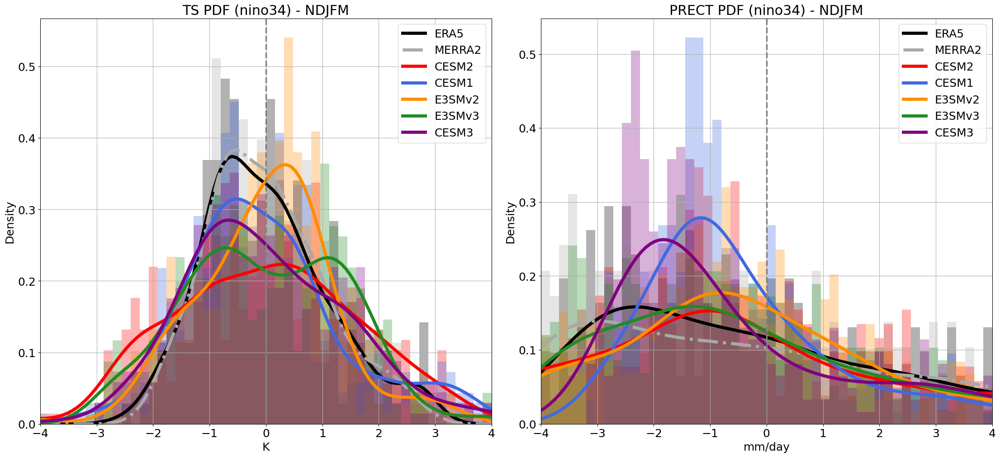

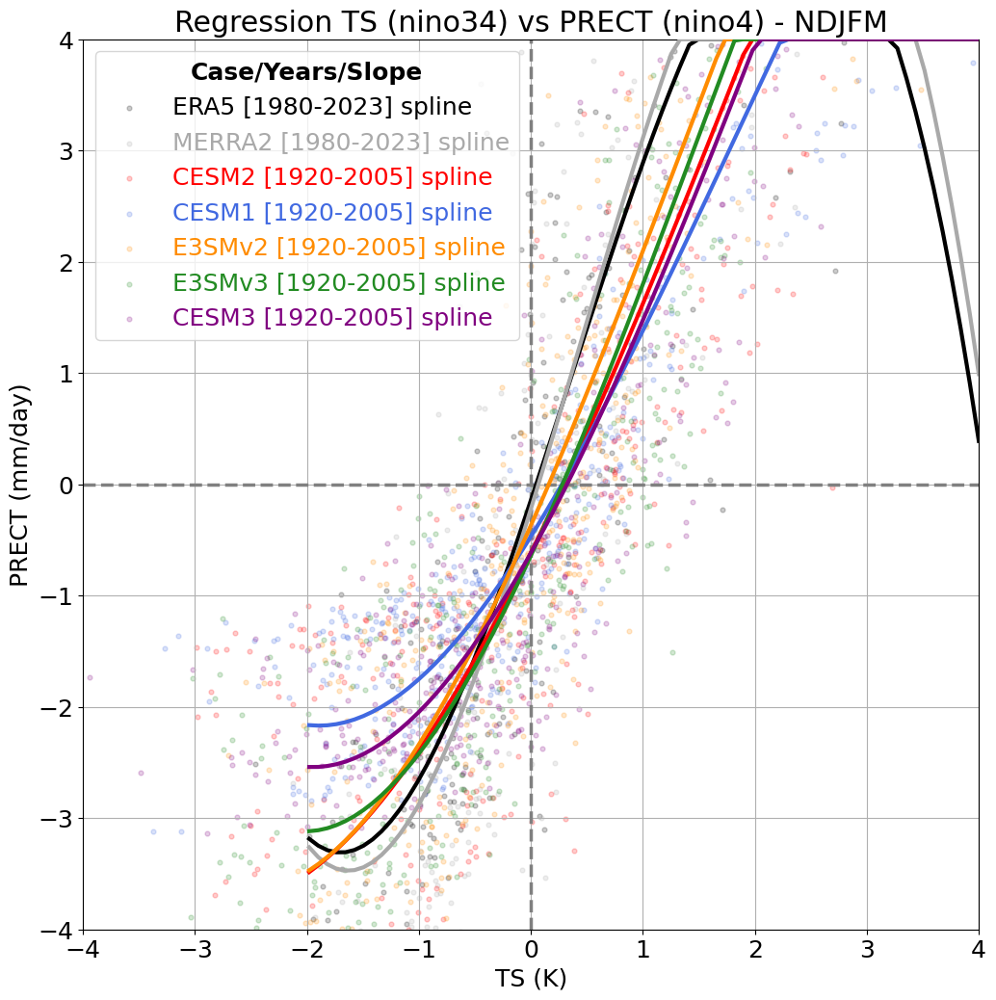

In [53]:
if DO_1D_PLOT:
    fig_pdf, ax_pdf = plt.subplots(nrows=1, ncols=2, constrained_layout=True, figsize=(22, 10))
    fig_scat, ax_scat = plt.subplots(nrows=1, ncols=1, figsize=(FIGXY, FIGXY))

    for d in cases_data:
        icase      = d['icase']
        col        = d['color']
        lstyle     = d['lstyle']
        lbl        = d['label']
        var_x_1d   = d['var_x_1d']
        var_y_1d   = d['var_y_1d']
        var_x_pdf  = d['var_x_pdf']
        var_y_pdf  = d['var_y_pdf']

        # VAR_X PDF
        ax_pdf[0].hist(var_x_1d, color=col, bins=int(0.5 * var_x_pdf.size),
                       range=(XMIN, XMAX), alpha=0.3, density=True)
        ax_pdf[0].plot(X_AVALS, var_x_pdf, linewidth=5, color=col,
                       linestyle=lstyle, label=lbl)

        # VAR_Y PDF
        ax_pdf[1].hist(var_y_1d, color=col, bins=int(0.5 * var_y_pdf.size),
                       range=(YMIN, YMAX), alpha=0.3, density=True)
        ax_pdf[1].plot(Y_AVALS, var_y_pdf, linewidth=5, color=col,
                       linestyle=lstyle, label=lbl)

        # Scatter / regression
        varx_even = np.linspace(XMIN, XMAX, 100)
        _do_nlr   = (VAR_X == 'TS' and VAR_Y == 'PRECT')
        if _do_nlr:
            _sx    = var_x_1d.values
            _sy    = var_y_1d.values
            _sord  = np.argsort(_sx)
            _spline = UnivariateSpline(_sx[_sord], _sy[_sord], k=3, s=10 * len(_sx))
            _line  = _spline(varx_even)
            fit_lbl = 'spline'
        else:
            _slope, _intercept, _, _, _ = linregress(var_x_1d, var_y_1d)
            _line   = _slope * varx_even + _intercept
            fit_lbl = f'{_slope:.3g}'

        case_yrs = f'{lbl} [{int(d["yr0"])}-{int(d["yr1"])}] {fit_lbl}'
        ax_scat.scatter(var_x_1d, var_y_1d, label=case_yrs, alpha=0.2, color=col, s=12)
        _xmask        = (varx_even >= -2.0) if _do_nlr else np.ones(len(varx_even), dtype=bool)
        _line_clipped = np.clip(_line[_xmask], YMIN, YMAX)
        ax_scat.plot(varx_even[_xmask], _line_clipped, color=col, linewidth=3,
                     linestyle='-' if _do_nlr else lstyle, zorder=5)

    # PDF axes formatting
    for ax_p, vname, vunits, vmin, vmax in [
            (ax_pdf[0], VAR_X, UNITS_X, XMIN, XMAX),
            (ax_pdf[1], VAR_Y, UNITS_Y, YMIN, YMAX)]:
        ax_p.set_xlim([vmin, vmax])
        ax_p.set_title(f'{vname} PDF ({NINO_X}) - {SEASON}')
        ax_p.set_xlabel(vunits)
        ax_p.set_ylabel('Density')
        ax_p.grid(True)
        ax_p.axvline(x=0., color='gray', linestyle='--', linewidth=2.5)
        ax_p.legend()

    # Scatter axis formatting
    ax_scat.set_xlabel(f'{VAR_X} ({UNITS_X})')
    ax_scat.set_xlim([XMIN, XMAX])
    ax_scat.set_ylabel(f'{VAR_Y} ({UNITS_Y})')
    ax_scat.set_ylim([YMIN, YMAX])
    ax_scat.set_title(f'Regression {VAR_X} ({NINO_X}) vs {VAR_Y} ({NINO_Y}) - {SEASON}')
    ax_scat.grid(True)
    ax_scat.axhline(0, color='gray', linestyle='--', linewidth=2.5)
    ax_scat.axvline(0, color='gray', linestyle='--', linewidth=2.5)
    legend = ax_scat.legend(title='Case/Years/Slope')
    legend.get_title().set_fontweight('bold')
    for ileg, leg_lab in enumerate(legend.get_texts()):
        leg_lab.set_color(COLORS[ileg])

    fig_pdf.savefig(fig_path(f'{VAR_X}_{VAR_Y}_{SEASON}_{NINO_X}_{NINO_Y}_1D_PDFs_monthly'))
    fig_scat.savefig(fig_path(f'{VAR_X}_{VAR_Y}_{SEASON}_{NINO_X}_{NINO_Y}_scatter_monthly'))
    plt.show()
    plt.close(fig_pdf)
    plt.close(fig_scat)

In [54]:
if DO_SST_LAG:
    for d in cases_data:
        print(f'SST lag maps: {d["label"]}')
        mypy.plot_sst_lag_corr_maps(
            d['da_x_all'], NINO_X, d['fcname'], d['yr0'], d['yr1'],
            DIR_FIG, FIG_PREFIX, FSCALE)

SST lag maps: ERA5
SST lag maps: MERRA2
SST lag maps: CESM2


/glade/work/rneale/conda-envs/neale_vproc2/lib/python3.14/site-packages/distributed/client.py:3375: UserWarning: Sending large graph of size 9.76 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/glade/work/rneale/conda-envs/neale_vproc2/lib/python3.14/site-packages/distributed/client.py:3375: UserWarning: Sending large graph of size 10.71 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


SST lag maps: CESM1


/glade/work/rneale/conda-envs/neale_vproc2/lib/python3.14/site-packages/distributed/client.py:3375: UserWarning: Sending large graph of size 10.05 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


SST lag maps: E3SMv2


/glade/work/rneale/conda-envs/neale_vproc2/lib/python3.14/site-packages/distributed/client.py:3375: UserWarning: Sending large graph of size 10.64 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


SST lag maps: E3SMv3


/glade/work/rneale/conda-envs/neale_vproc2/lib/python3.14/site-packages/distributed/client.py:3375: UserWarning: Sending large graph of size 12.89 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/glade/work/rneale/conda-envs/neale_vproc2/lib/python3.14/site-packages/distributed/client.py:3375: UserWarning: Sending large graph of size 15.58 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


SST lag maps: CESM3


---
## Cross-Pacific Cross Section

Longitude × NINO_X bin contourf: `VAR_XPACIFIC` anomalies lat-averaged between `XPACIFIC_LAT_S` and `XPACIFIC_LAT_N`, binned by the same NINO_X SST anomaly bins used in the 3D pressure-level plots. One figure per case. Red dashed lines mark the NINO_X region longitude bounds.


Cross-Pacific (PRECT): ERA5
  - Grabbing  ERA5  data for PRECT
  - Requested variable year range =  1980 - 2023
  - Time details for x-axis - TS
    - Available year range =  1980.Jan - 2023.Dec
  - Time details for y-axis - PRECT
    - Available year range =  1940.Jan - 2023.Dec
    - DataArray time range of axes do not match
    - Common time range: 1980-01-01 – 2023-12-01  (220 steps)


/glade/work/rneale/conda-envs/neale_vproc2/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


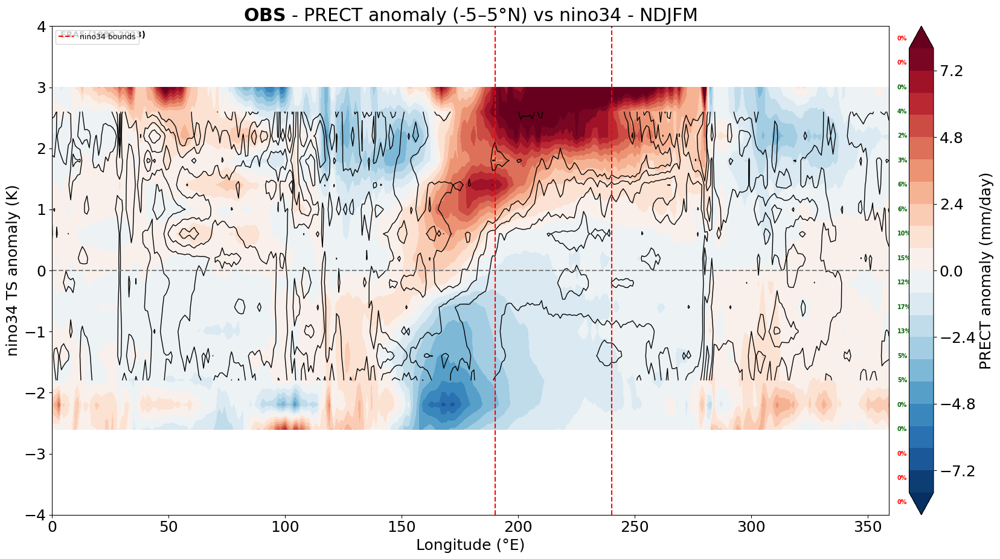


Cross-Pacific (PRECT): MERRA2
  - Grabbing  MERRA2  data for PRECT
  - Requested variable year range =  1980 - 2023
  - Time details for x-axis - TS
    - Available year range =  1980.Jan - 2023.Dec
  - Time details for y-axis - PRECT
    - Available year range =  1980.Jan - 2023.Dec
    - DataArray time range of axes do not match
    - Common time range: 1980-01-01 – 2023-12-01  (220 steps)


/glade/work/rneale/conda-envs/neale_vproc2/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


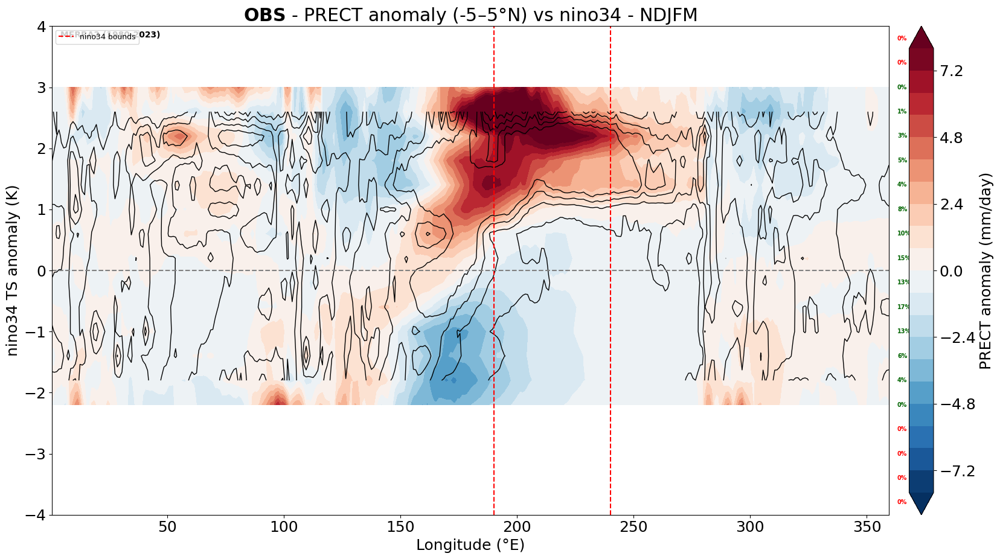


Cross-Pacific (PRECT): CESM2
  - Grabbing file(s) for CESM2
  - Requested variable year range =  1920 - 2005
  - Time details for x-axis - TS
    - Available year range =  1920.Jan - 2005.Dec
  - Time details for y-axis - PRECT
    - Available year range =  1850.Feb - 2015.Jan
    - DataArray time range of axes do not match
    - Common time range: 1920-01-01 – 2005-12-01  (430 steps)


/glade/work/rneale/conda-envs/neale_vproc2/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


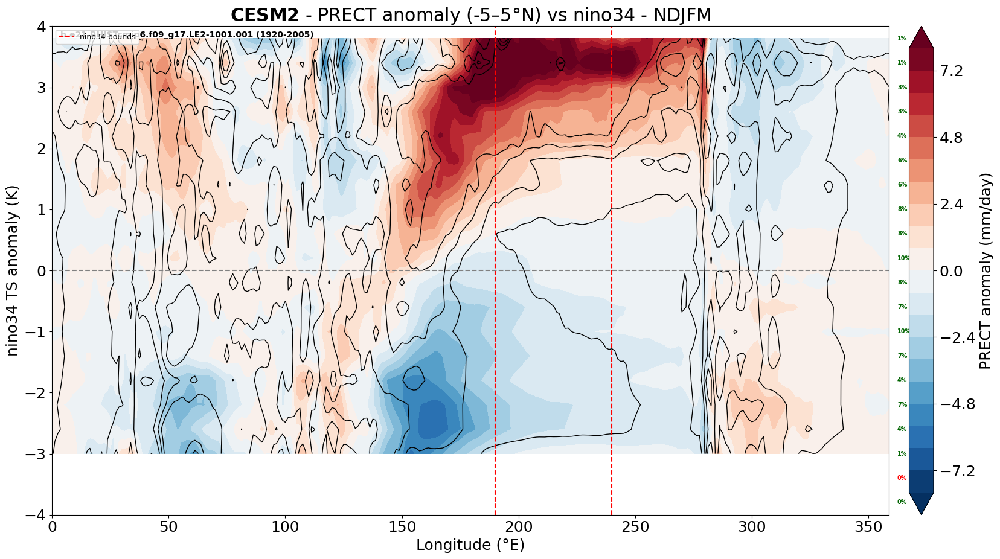


Cross-Pacific (PRECT): CESM1
  - Grabbing file(s) for CESM1
  - Requested variable year range =  1920 - 2005
  - Time details for x-axis - TS
    - Available year range =  1920.Jan - 2005.Dec
  - Time details for y-axis - PRECT
    - Available year range =  1850.Feb - 2006.Jan
    - DataArray time range of axes do not match
    - Common time range: 1920-01-01 – 2005-12-01  (430 steps)


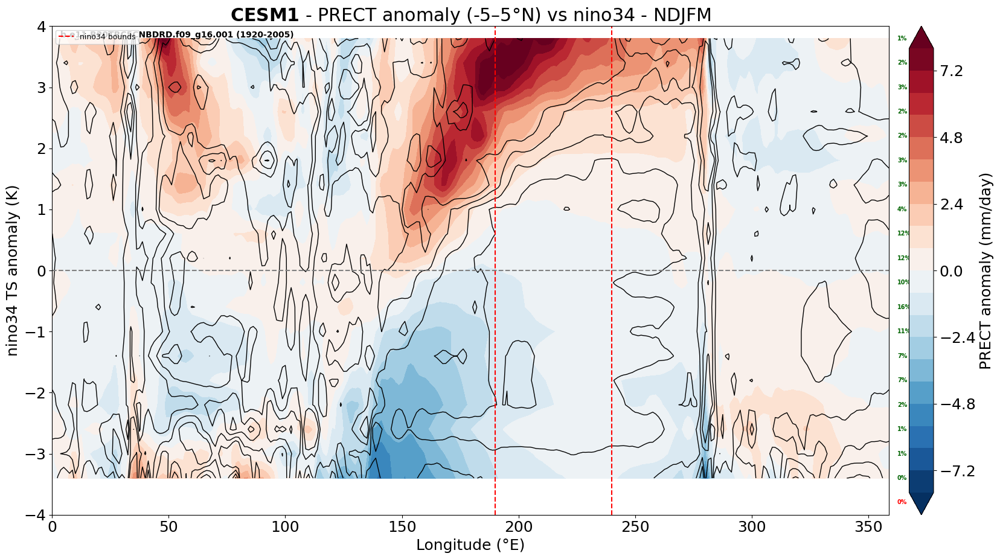


Cross-Pacific (PRECT): E3SMv2
  - Grabbing E3SM file(s) for PRECT
  - Requested variable year range =  1920 - 2005
  - Time details for x-axis - TS
    - Available year range =  1920.Jan - 2005.Dec
  - Time details for y-axis - PRECT
    - Available year range =  1850.Feb - 2015.Jan
    - DataArray time range of axes do not match
    - Common time range: 1920-01-01 – 2005-12-01  (430 steps)


/glade/work/rneale/conda-envs/neale_vproc2/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


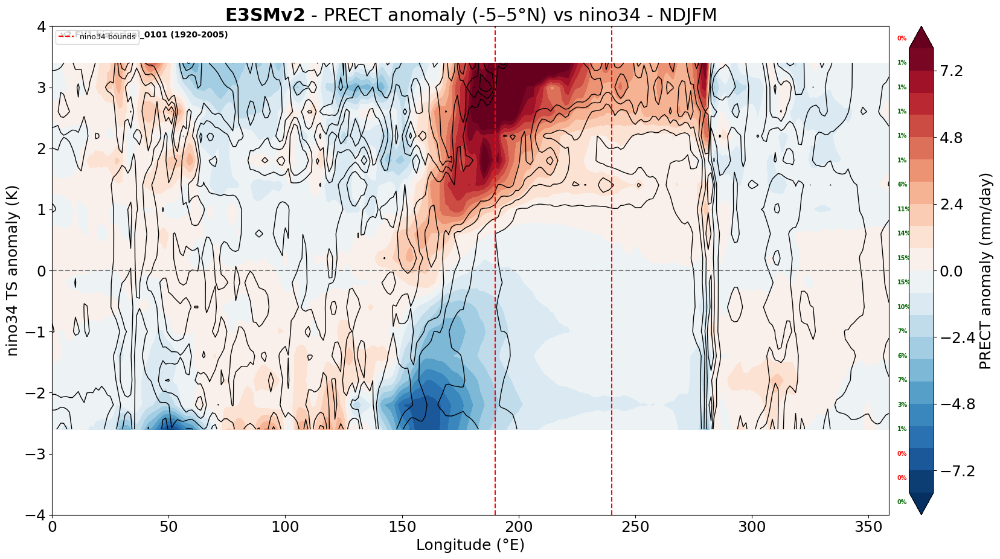


Cross-Pacific (PRECT): E3SMv3
  - Grabbing E3SMv3 file(s) for PRECT


/glade/work/rneale/git/python-scripts/papers/ENSO_vprocs_fbacks/claude_code/enso_feedbacks_utils.py:1076: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  da_pc = xr.open_mfdataset(files_pc, parallel=True, combine="by_coords",
/glade/work/rneale/git/python-scripts/papers/ENSO_vprocs_fbacks/claude_code/enso_feedbacks_utils.py:1076: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_def

  - Requested variable year range =  1920 - 2005
  - Time details for x-axis - TS
    - Available year range =  1920.Jan - 2005.Dec
  - Time details for y-axis - PRECT
    - Available year range =  1850.Feb - 2051.Jan
    - DataArray time range of axes do not match
    - Common time range: 1920-01-01 – 2005-12-01  (430 steps)


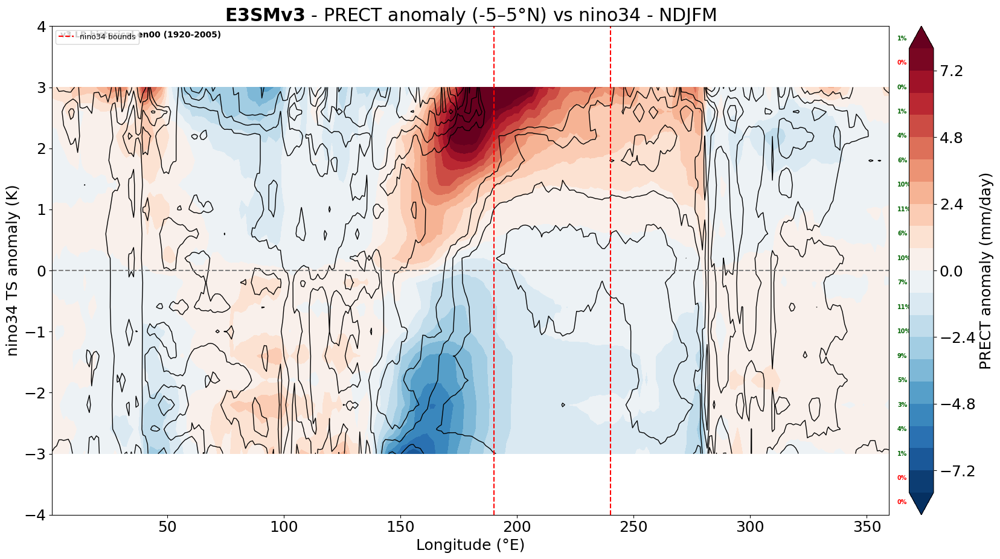


Cross-Pacific (PRECT): CESM3
   - Cecile's Run
   - Found 1968 monthly hist files in /glade/derecho/scratch/hannay/archive/b.e30_alpha08b.BHISTC_LTso.ne30_t232_wgx3.315/atm/hist/
   - Using 1032 files for years 1920–2005
   - Using cached CESM3 dataset
  - Requested variable year range =  1920 - 2005
  - Time details for x-axis - TS
    - Available year range =  1920.Jan - 2005.Dec
  - Time details for y-axis - PRECT
    - Available year range =  1920.Jan - 2005.Dec
    - DataArray time range of axes do not match
    - Common time range: 1920-01-01 – 2005-12-01  (430 steps)


/glade/work/rneale/conda-envs/neale_vproc2/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


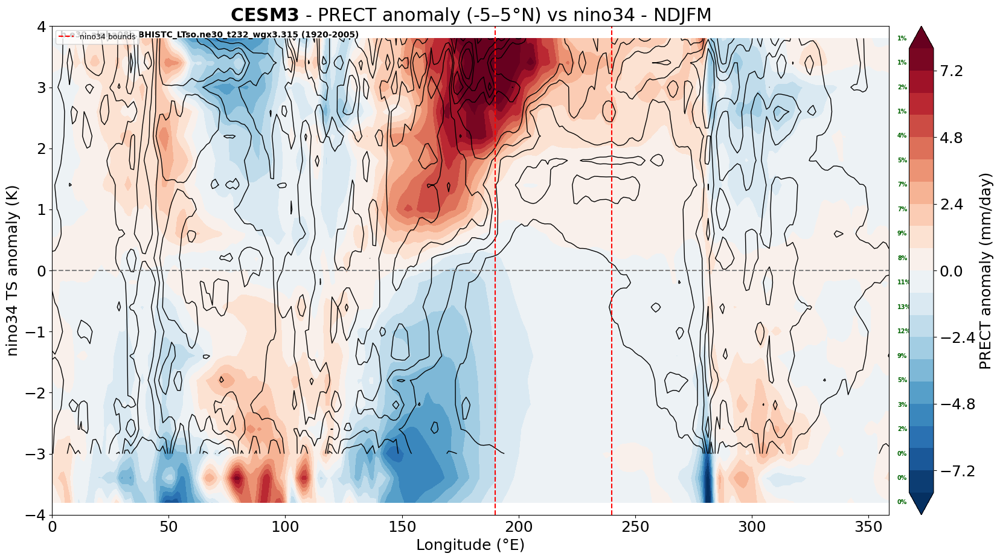

In [55]:
if DO_XPACIFIC:
    _same_as_varx = (VAR_XPACIFIC == VAR_X)
    _nw_pac, _ne_pac, _, _ = mypy.nino_region(NINO_X)

    for d in cases_data:
        fcname    = d['fcname']
        ctype     = d['ctype']
        cnames    = d['cnames']
        case_type = d['case_type']
        yr0       = d['yr0']
        yr1       = d['yr1']
        da_x      = d['da_x']
        var_x_1d  = d['var_x_1d']

        print(f'\nCross-Pacific ({VAR_XPACIFIC}): {d["label"]}')

        # Load (or reuse) the cross-Pacific variable
        if _same_as_varx:
            da_xpac_raw = da_x
        else:
            da_xpac_raw = mypy.get_dataset(cnames[-1], ctype, VAR_XPACIFIC, yr0, yr1,
                                           READ_ALL_HIST, WRITE_TS_FILE, READ_TS_FILE)
            _, da_xpac_raw = mypy.dataset_ts_trim(
                da_x, da_xpac_raw, yr0, yr1, VAR_X, VAR_XPACIFIC, GET_MONTHS)

        # Monthly anomalies then lat-average between XPACIFIC_LAT_S and XPACIFIC_LAT_N
        da_xpac_anom = mypy.monthly_anom(da_xpac_raw)
        da_xpac_lat  = (da_xpac_anom
                        .sortby('lat')
                        .sel(lat=slice(XPACIFIC_LAT_S, XPACIFIC_LAT_N)))
        wts          = np.cos(np.deg2rad(da_xpac_lat.lat))
        da_xpac_2d   = da_xpac_lat.weighted(wts).mean('lat').compute()  # (time, lon)

        # Align with NINO_X index then bin by SST anomaly (reuses same BIN_EDGES as 3D plots)
        da_xpac_2d, _vx = xr.align(da_xpac_2d, var_x_1d, join='inner')
        xpac_binned, xpac_var, xpac_counts = mypy.bin_mean_var_by_level(
            da_xpac_2d, _vx, BIN_EDGES, BIN_CENTERS, lev_dim='lon')

        # Auto-set variability contour levels from 90th-percentile of std
        _xpac_vmax = float(np.nanpercentile(xpac_var.values, 90))
        if _xpac_vmax > 0:
            _mag  = 10 ** np.floor(np.log10(_xpac_vmax / 4))
            _step = max(np.round(_xpac_vmax / (4 * _mag)) * _mag, _mag)
            _xpac_slevels = np.arange(_step, _xpac_vmax * 1.05, _step)
        else:
            _xpac_slevels = np.array([0.1, 0.5, 1.])

        # ── Figure: longitude (x) × NINO_X bin (y) ──────────────────────────────
        fig_xp, ax_xp = plt.subplots(1, 1, figsize=(FIGXY * 1.5, FIGXY * 0.8))

        dlev_xp   = (CRANGE_XPAC[1] - CRANGE_XPAC[0]) / N_BINS
        levels_xp = np.arange(CRANGE_XPAC[0], CRANGE_XPAC[1] + dlev_xp, dlev_xp)

        # xpac_binned dims: (lon, bin) → transpose to (bin, lon) for contourf
        cf_xp = ax_xp.contourf(xpac_binned.lon, xpac_binned.bin, xpac_binned.T,
                               levels=levels_xp, cmap='RdBu_r', extend='both')
        plt.colorbar(cf_xp, ax=ax_xp,
                     label=f'{VAR_XPACIFIC} anomaly ({UNITS_XPACIFIC})', pad=0.02)
        ax_xp.contour(xpac_var.lon, xpac_var.bin, xpac_var.T,
                      levels=_xpac_slevels, linewidths=1.0, colors='black')

        # NINO_X region longitude bounds
        ax_xp.axvline(_nw_pac, color='red', linestyle='--', linewidth=1.5)
        ax_xp.axvline(_ne_pac, color='red', linestyle='--', linewidth=1.5,
                      label=f'{NINO_X} bounds')

        ax_xp.axhline(0., color='gray', linestyle='--', linewidth=1.5)
        ax_xp.set_xlabel('Longitude (°E)')
        ax_xp.set_ylabel(f'{NINO_X} {VAR_X} anomaly ({UNITS_X})')
        ax_xp.set_ylim([XMIN, XMAX])
        ax_xp.set_title(
            r'$\bf{' + case_type + r'}$ - '
            + f'{VAR_XPACIFIC} anomaly '
            + f'({XPACIFIC_LAT_S:.0f}–{XPACIFIC_LAT_N:.0f}°N) '
            + f'vs {NINO_X} - {SEASON}',
            usetex=False)
        ax_xp.text(0.01, 0.99, f'{fcname} ({yr0}-{yr1})',
                   transform=ax_xp.transAxes, ha='left', va='top',
                   fontweight='bold', fontsize=10 * FSCALE)

        # Bin-count percentages along the right edge
        _btr = mtransforms.blended_transform_factory(ax_xp.transAxes, ax_xp.transData)
        _tot = xpac_counts.sum()
        for _bc, _cnt in zip(BIN_CENTERS, xpac_counts):
            _pct = 100.0 * _cnt / _tot if _tot > 0 else 0.0
            ax_xp.text(1.01, _bc, f'{_pct:.0f}%', transform=_btr,
                       ha='left', va='center', fontsize=7 * FSCALE,
                       color='red' if _cnt == 0 else 'darkgreen', fontweight='bold')

        ax_xp.legend(loc='upper left', fontsize=9)
        fig_xp.tight_layout()

        _fstem = f'{fcname}_{VAR_X}_{VAR_XPACIFIC}_{SEASON}_{NINO_X}_xpacific'
        fig_xp.savefig(fig_path(_fstem), dpi=150, bbox_inches='tight')
        plt.show()
        plt.close(fig_xp)

---
## 3D Pressure-Level Analysis


3D binned: ERA5
  - Grabbing  ERA5  data for OMEGA
  - Requested variable year range =  1980 - 2023
  - Time details for x-axis - TS
    - Available year range =  1980.Jan - 2023.Dec
  - Time details for y-axis - OMEGA
    - Available year range =  1940.Jan - 2023.Dec
    - DataArray time range of axes do not match
    - Common time range: 1980-01-01 – 2023-12-01  (220 steps)


/glade/work/rneale/conda-envs/neale_vproc2/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


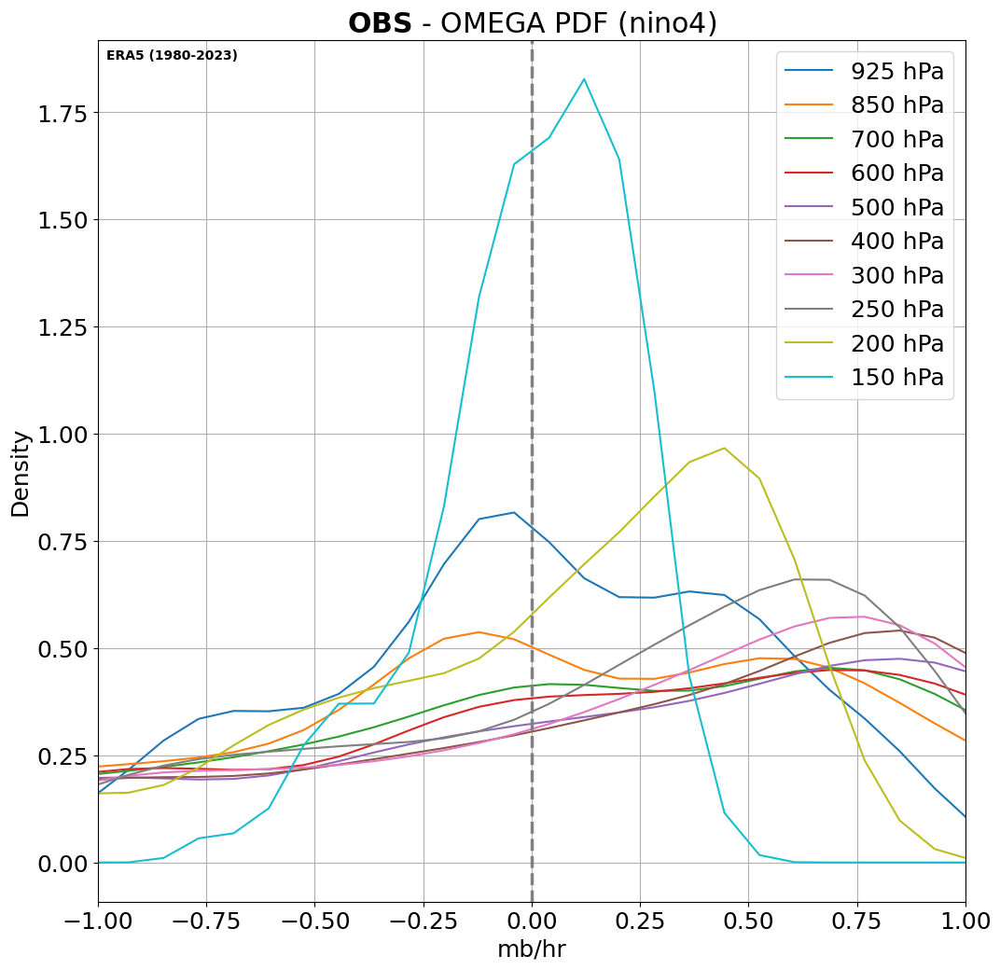

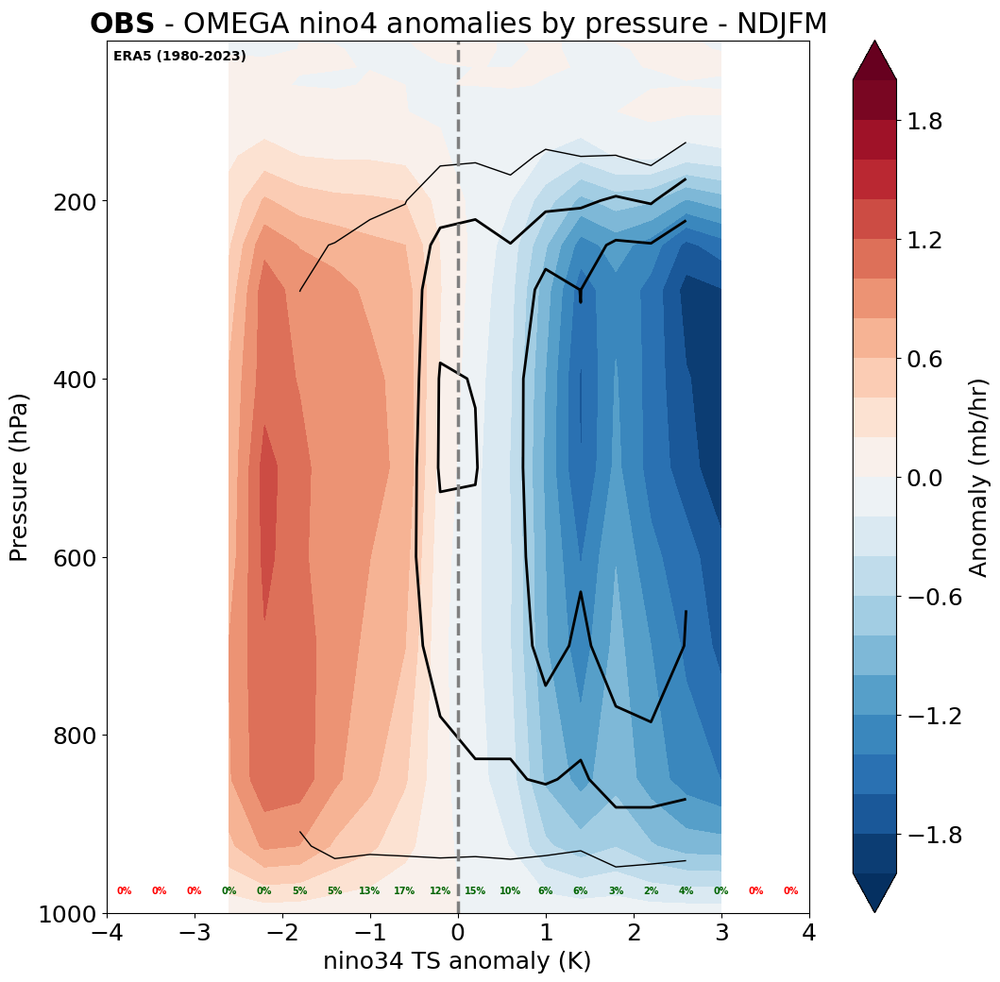


3D binned: MERRA2
  - Grabbing  MERRA2  data for OMEGA
  - Requested variable year range =  1980 - 2023
  - Time details for x-axis - TS
    - Available year range =  1980.Jan - 2023.Dec
  - Time details for y-axis - OMEGA
    - Available year range =  1980.Jan - 2023.Dec
    - DataArray time range of axes do not match
    - Common time range: 1980-01-01 – 2023-12-01  (220 steps)


/glade/work/rneale/conda-envs/neale_vproc2/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


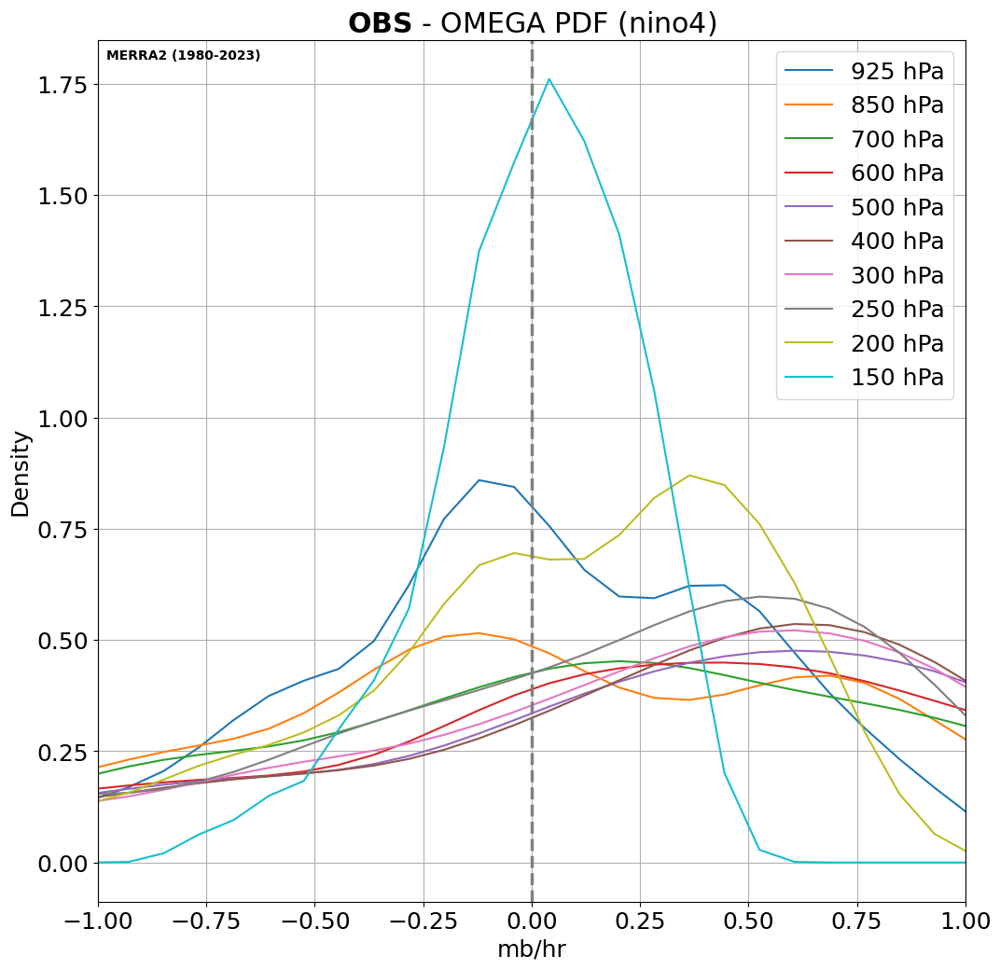

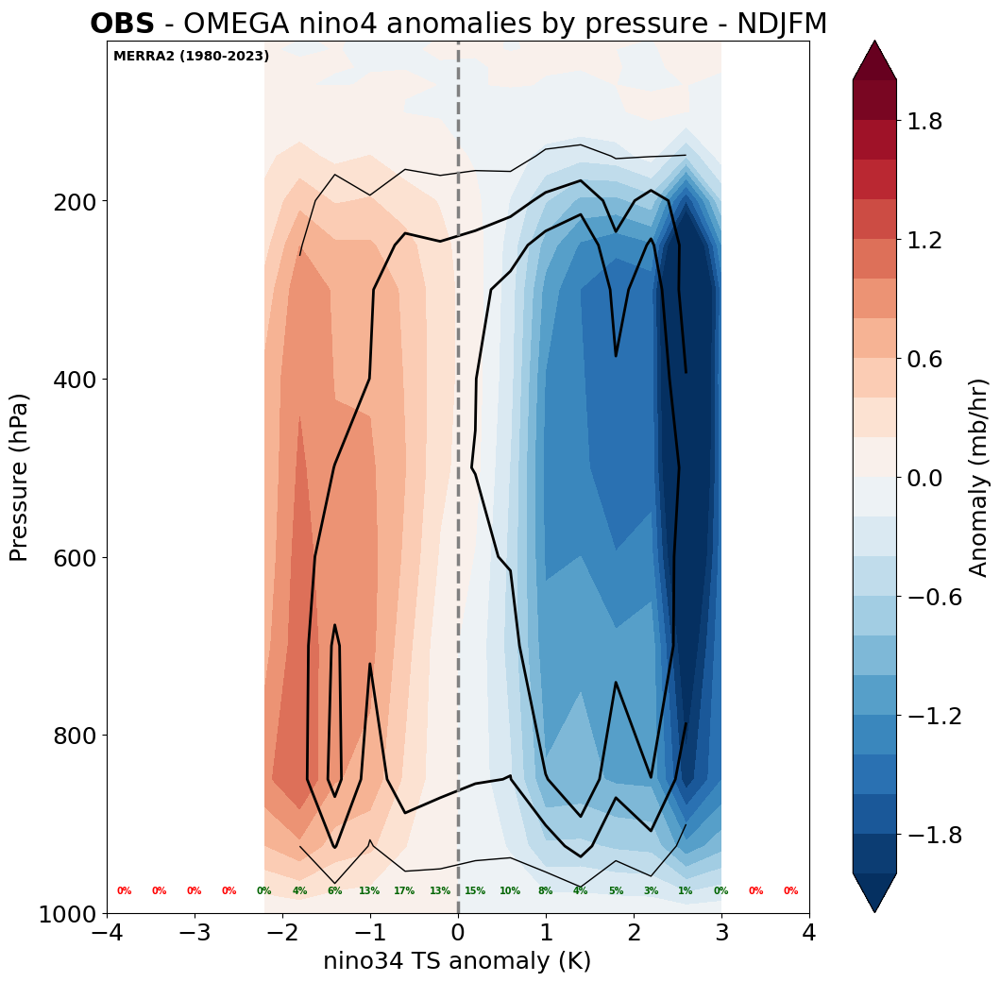


3D binned: CESM2
  - Grabbing file(s) for CESM2
-Interpolating  OMEGA  to  [100000.  92500.  85000.  70000.  60000.  50000.  40000.  30000.  25000.
  20000.  15000.  10000.   7000.   5000.   3000.   2000.]  mb
Done
  - Requested variable year range =  1920 - 2005
  - Time details for x-axis - TS
    - Available year range =  1920.Jan - 2005.Dec
  - Time details for y-axis - OMEGA
    - Available year range =  1850.Feb - 2015.Jan
    - DataArray time range of axes do not match
    - Common time range: 1920-01-01 – 2005-12-01  (430 steps)


/glade/work/rneale/conda-envs/neale_vproc2/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


  Ensemble: loading 1 members ...
    b.e21.BHISTcmip6.f09_g17.LE2-1001.001
  - Grabbing file(s) for CESM2
  - Grabbing file(s) for CESM2
-Interpolating  OMEGA  to  [100000.  92500.  85000.  70000.  60000.  50000.  40000.  30000.  25000.
  20000.  15000.  10000.   7000.   5000.   3000.   2000.]  mb
Done
  - Requested variable year range =  1920 - 2005
  - Time details for x-axis - TS
    - Available year range =  1850.Feb - 2015.Jan
  - Time details for y-axis - OMEGA
    - Available year range =  1850.Feb - 2015.Jan
    - DataArray time range of axes do not match
    - Common time range: 1920-01-01 – 2005-12-01  (430 steps)


/glade/work/rneale/conda-envs/neale_vproc2/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


  Ensemble: 1 members loaded


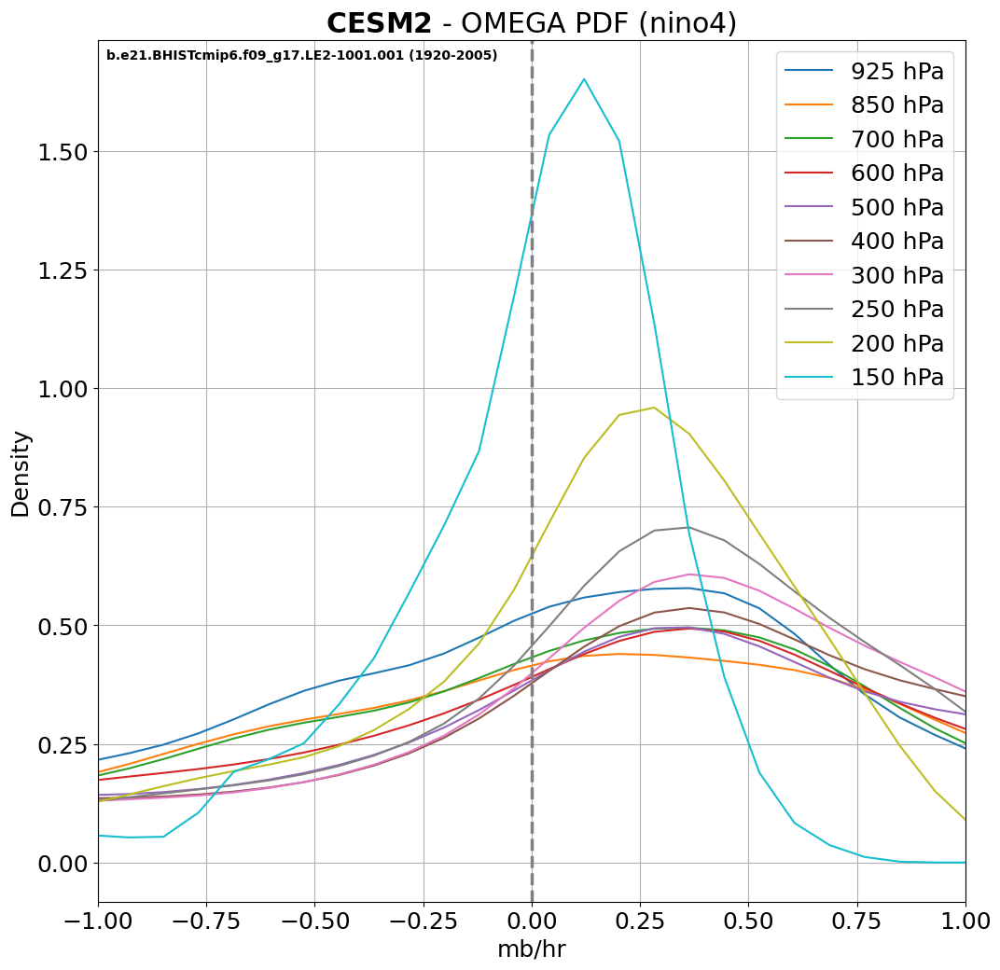

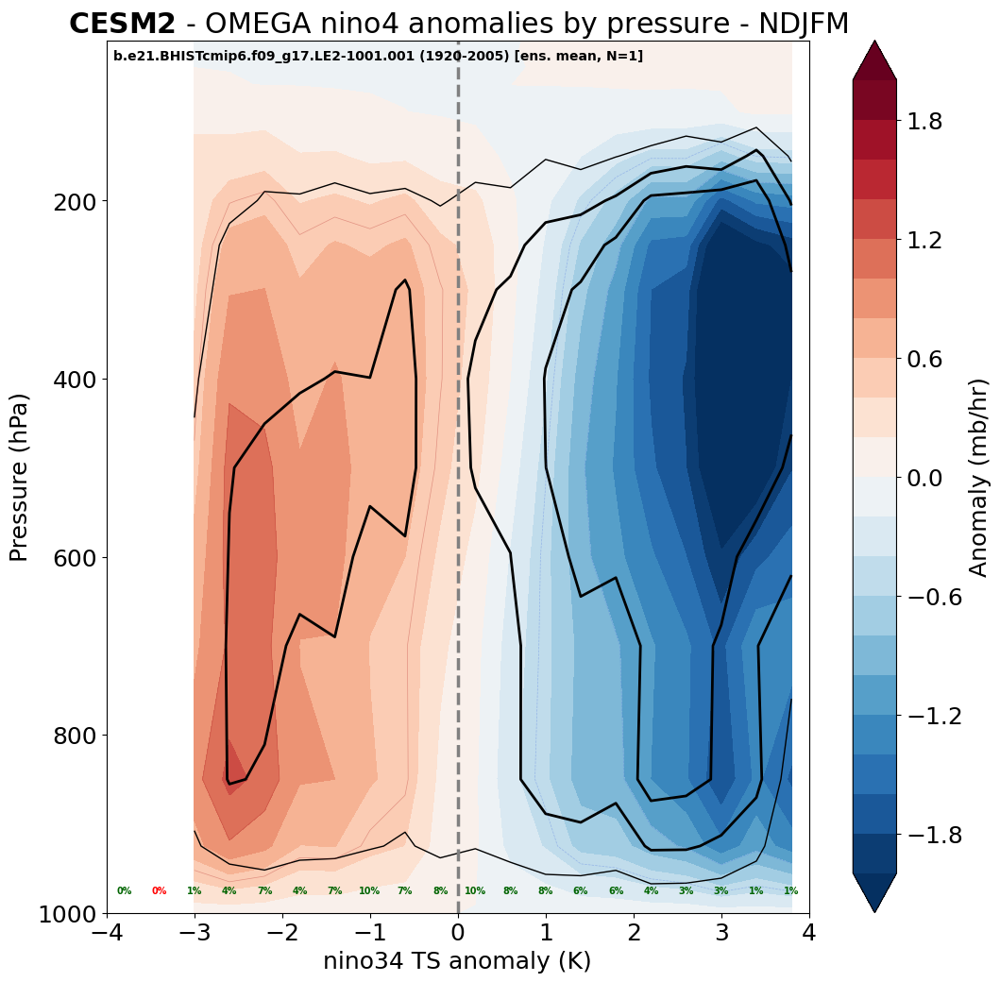


3D binned: CESM1
  - Grabbing file(s) for CESM1
-Interpolating  OMEGA  to  [100000.  92500.  85000.  70000.  60000.  50000.  40000.  30000.  25000.
  20000.  15000.  10000.   7000.   5000.   3000.   2000.]  mb
Done
  - Requested variable year range =  1920 - 2005
  - Time details for x-axis - TS
    - Available year range =  1920.Jan - 2005.Dec
  - Time details for y-axis - OMEGA
    - Available year range =  1850.Feb - 2006.Jan
    - DataArray time range of axes do not match
    - Common time range: 1920-01-01 – 2005-12-01  (430 steps)
  Ensemble: loading 1 members ...
    b.e11.B20TRC5CNBDRD.f09_g16.001
  - Grabbing file(s) for CESM1
  - Grabbing file(s) for CESM1
-Interpolating  OMEGA  to  [100000.  92500.  85000.  70000.  60000.  50000.  40000.  30000.  25000.
  20000.  15000.  10000.   7000.   5000.   3000.   2000.]  mb
Done
  - Requested variable year range =  1920 - 2005
  - Time details for x-axis - TS
    - Available year range =  1850.Feb - 2006.Jan
  - Time details for y-ax

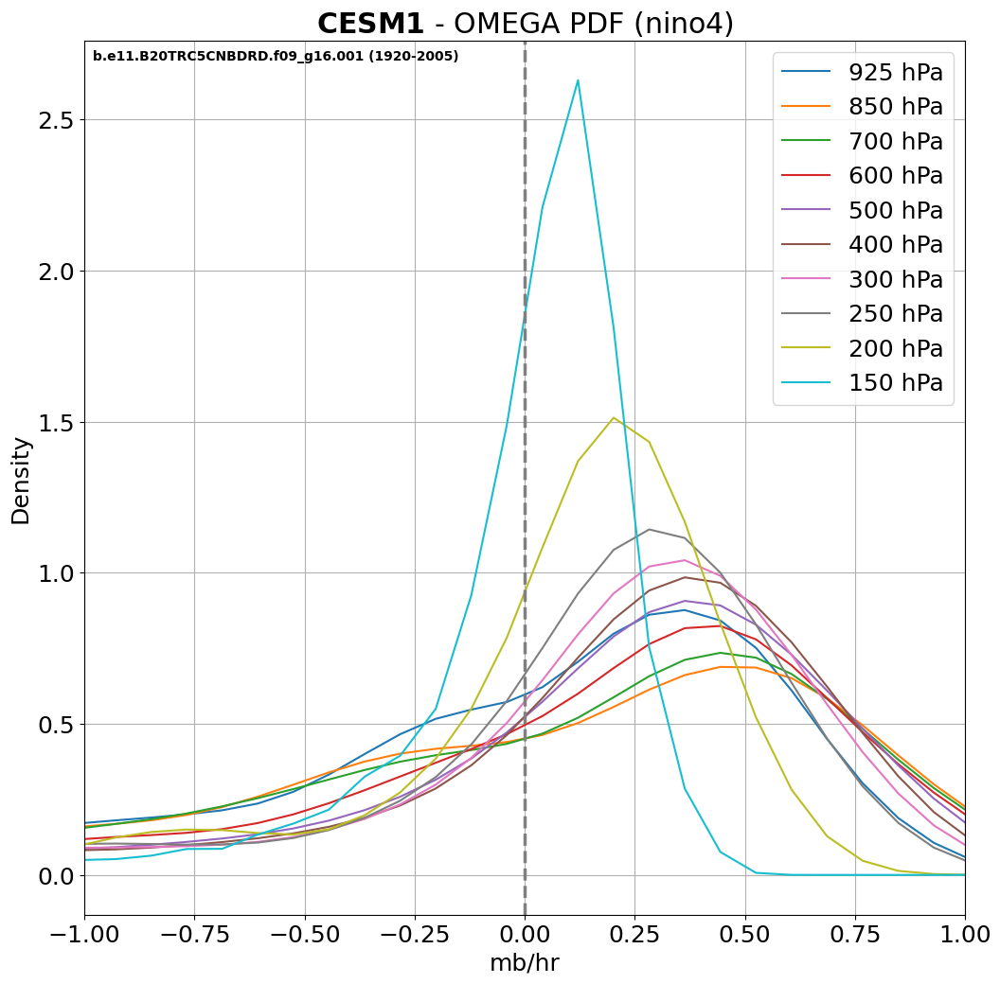

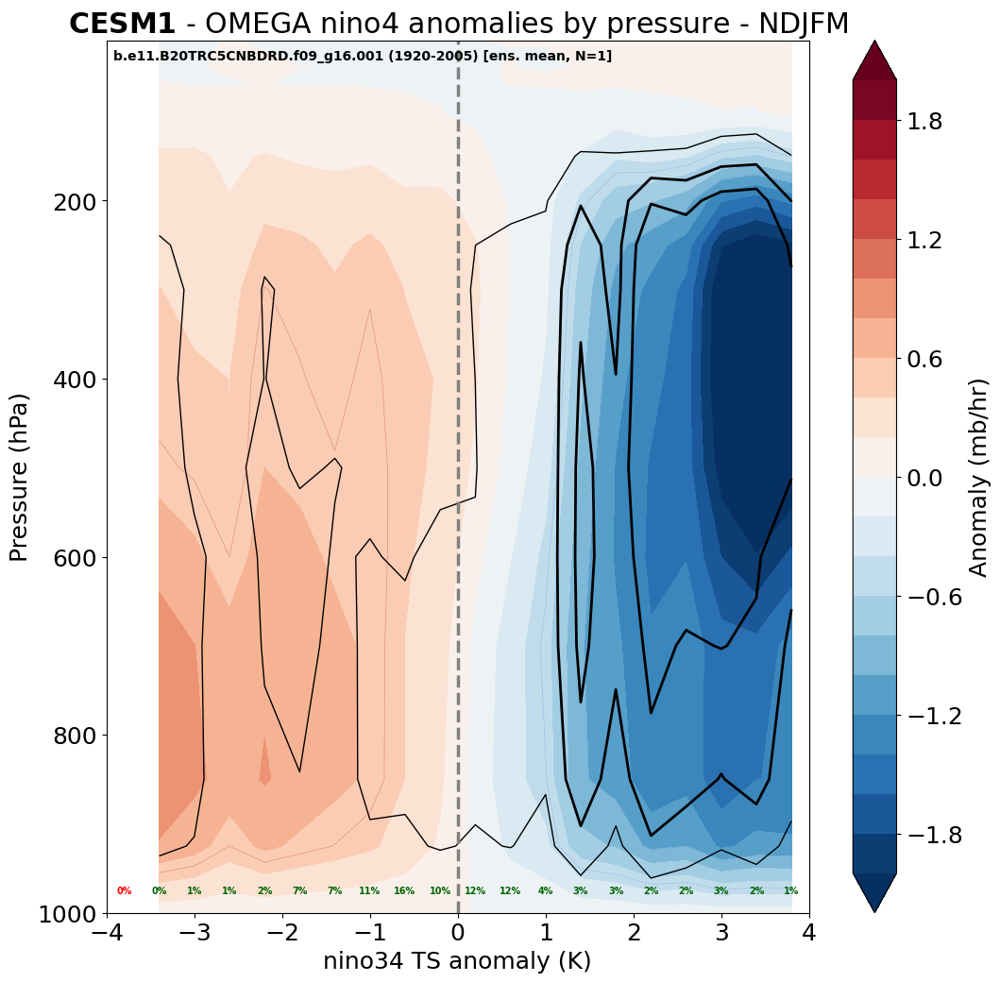


3D binned: E3SMv2
  - Grabbing E3SM file(s) for OMEGA
-Interpolating  OMEGA  to  [100000.  92500.  85000.  70000.  60000.  50000.  40000.  30000.  25000.
  20000.  15000.  10000.   7000.   5000.   3000.   2000.]  mb
Done
  - Requested variable year range =  1920 - 2005
  - Time details for x-axis - TS
    - Available year range =  1920.Jan - 2005.Dec
  - Time details for y-axis - OMEGA
    - Available year range =  1850.Feb - 2015.Jan
    - DataArray time range of axes do not match
    - Common time range: 1920-01-01 – 2005-12-01  (430 steps)


/glade/work/rneale/conda-envs/neale_vproc2/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


  Ensemble: loading 1 members ...
    v2.FV1.historical_0101
  - Grabbing E3SM file(s) for TS
  - Grabbing E3SM file(s) for OMEGA
-Interpolating  OMEGA  to  [100000.  92500.  85000.  70000.  60000.  50000.  40000.  30000.  25000.
  20000.  15000.  10000.   7000.   5000.   3000.   2000.]  mb
Done
  - Requested variable year range =  1920 - 2005
  - Time details for x-axis - TS
    - Available year range =  1850.Feb - 2015.Jan
  - Time details for y-axis - OMEGA
    - Available year range =  1850.Feb - 2015.Jan
    - DataArray time range of axes do not match
    - Common time range: 1920-01-01 – 2005-12-01  (430 steps)


/glade/work/rneale/conda-envs/neale_vproc2/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


  Ensemble: 1 members loaded


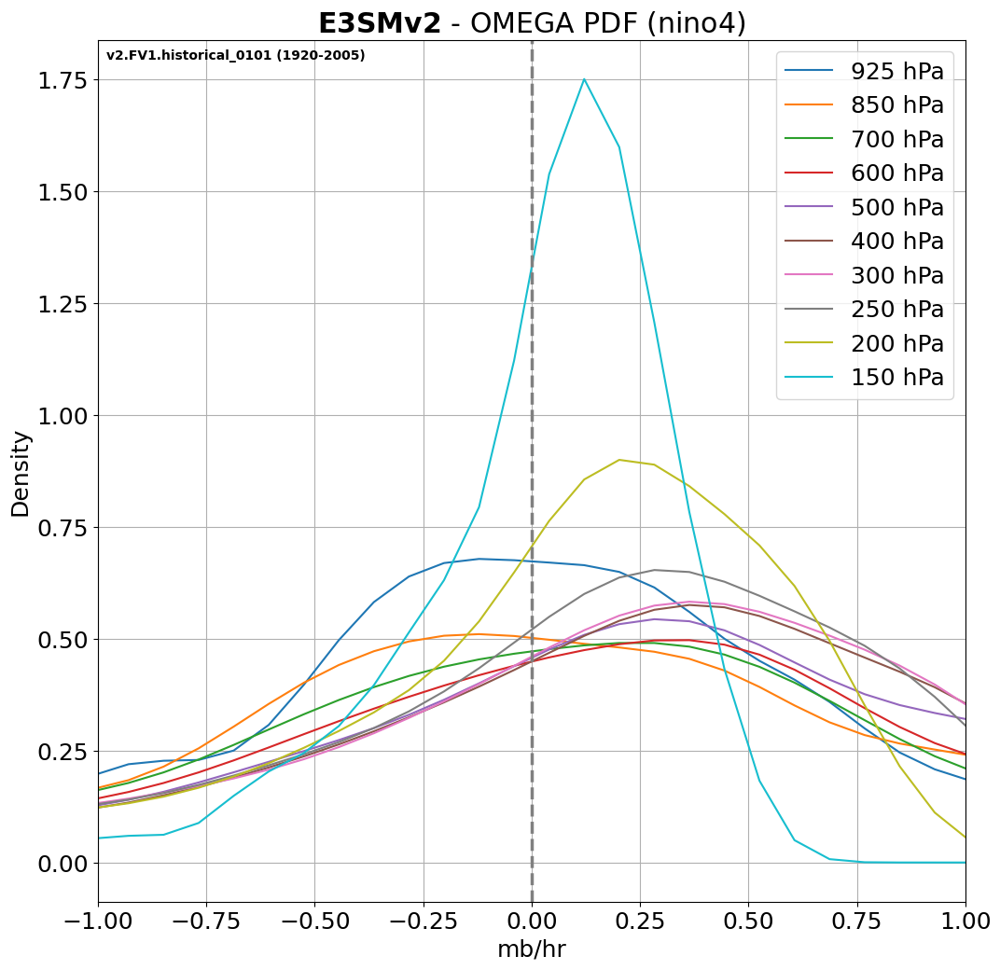

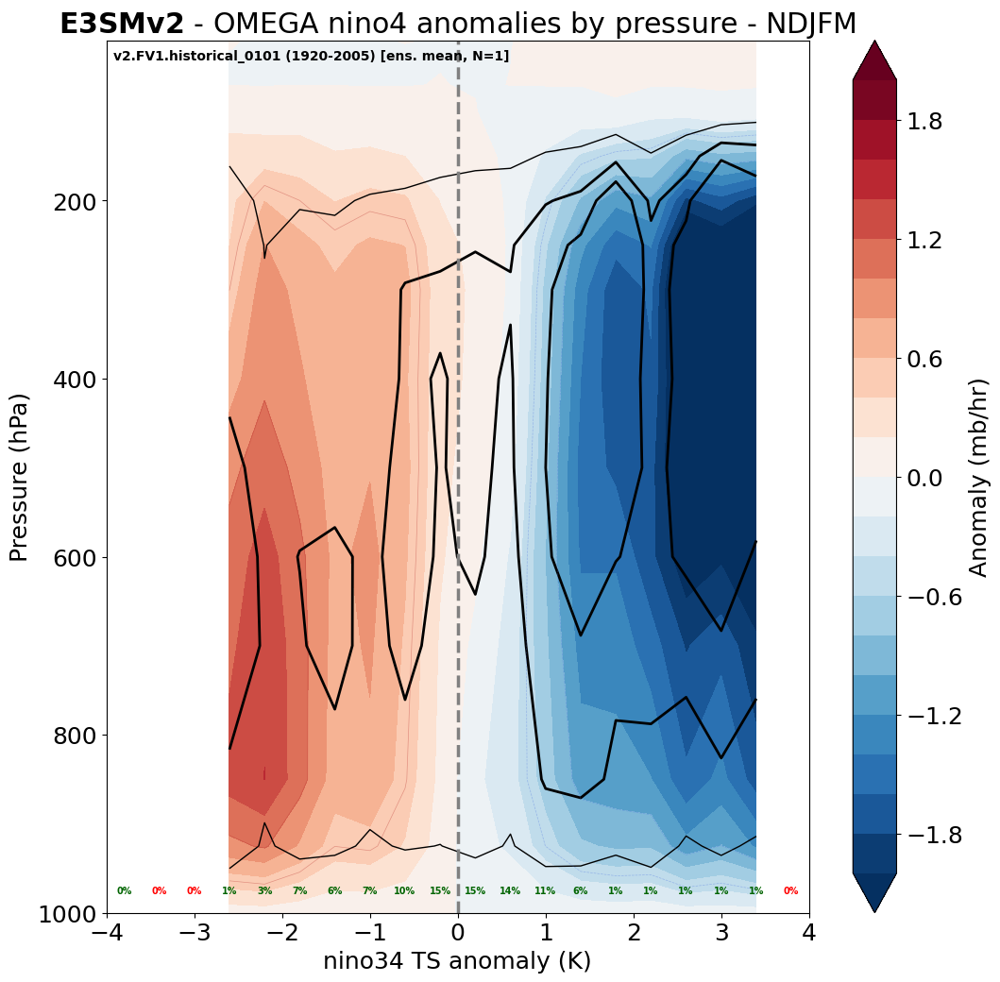


3D binned: E3SMv3
  - Grabbing E3SMv3 file(s) for OMEGA
  - Requested variable year range =  1920 - 2005
  - Time details for x-axis - TS
    - Available year range =  1920.Jan - 2005.Dec
  - Time details for y-axis - OMEGA
    - Available year range =  1850.Feb - 2051.Jan
    - DataArray time range of axes do not match
    - Common time range: 1920-01-01 – 2005-12-01  (430 steps)
  Ensemble: loading 1 members ...
    v3.LR.historical.en00
  - Grabbing E3SMv3 file(s) for TS
  - Grabbing E3SMv3 file(s) for OMEGA
  - Requested variable year range =  1920 - 2005
  - Time details for x-axis - TS
    - Available year range =  1850.Feb - 2051.Jan
  - Time details for y-axis - OMEGA
    - Available year range =  1850.Feb - 2051.Jan
    - DataArray time range of axes do not match
    - Common time range: 1920-01-01 – 2005-12-01  (430 steps)
  Ensemble: 1 members loaded


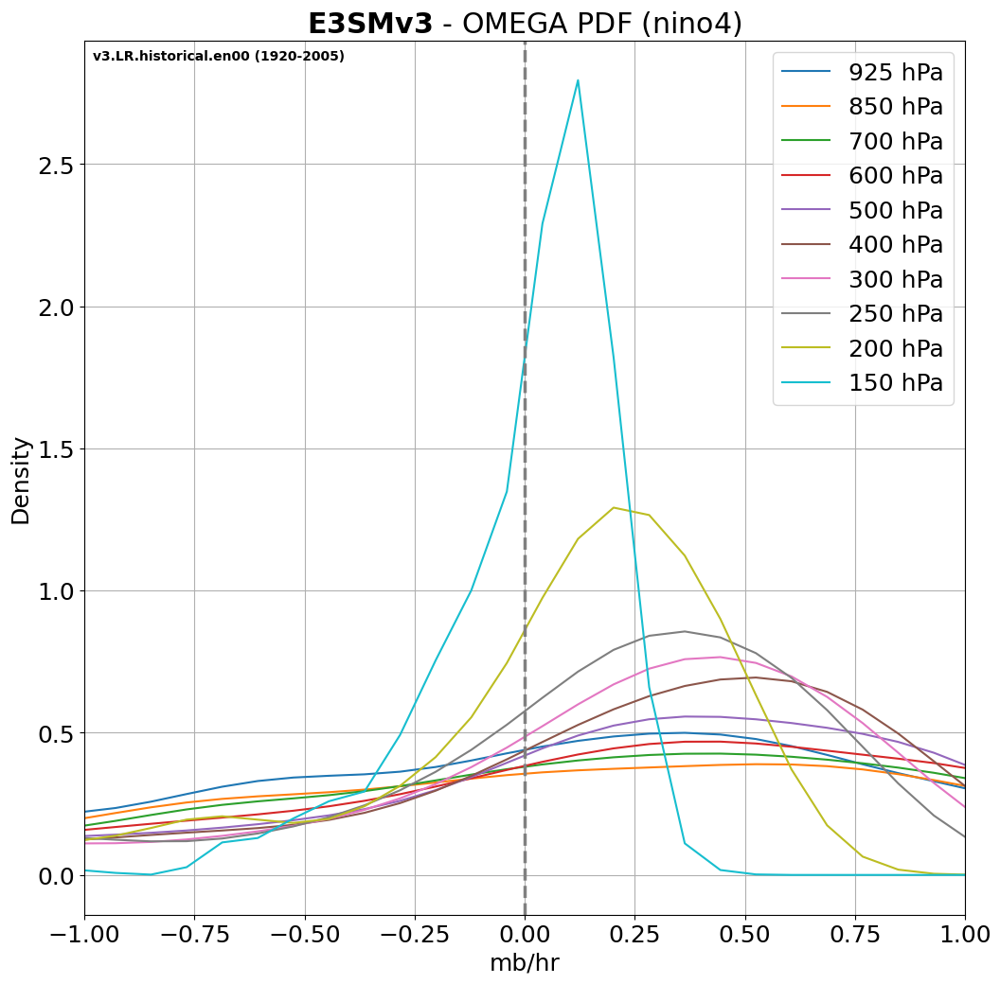

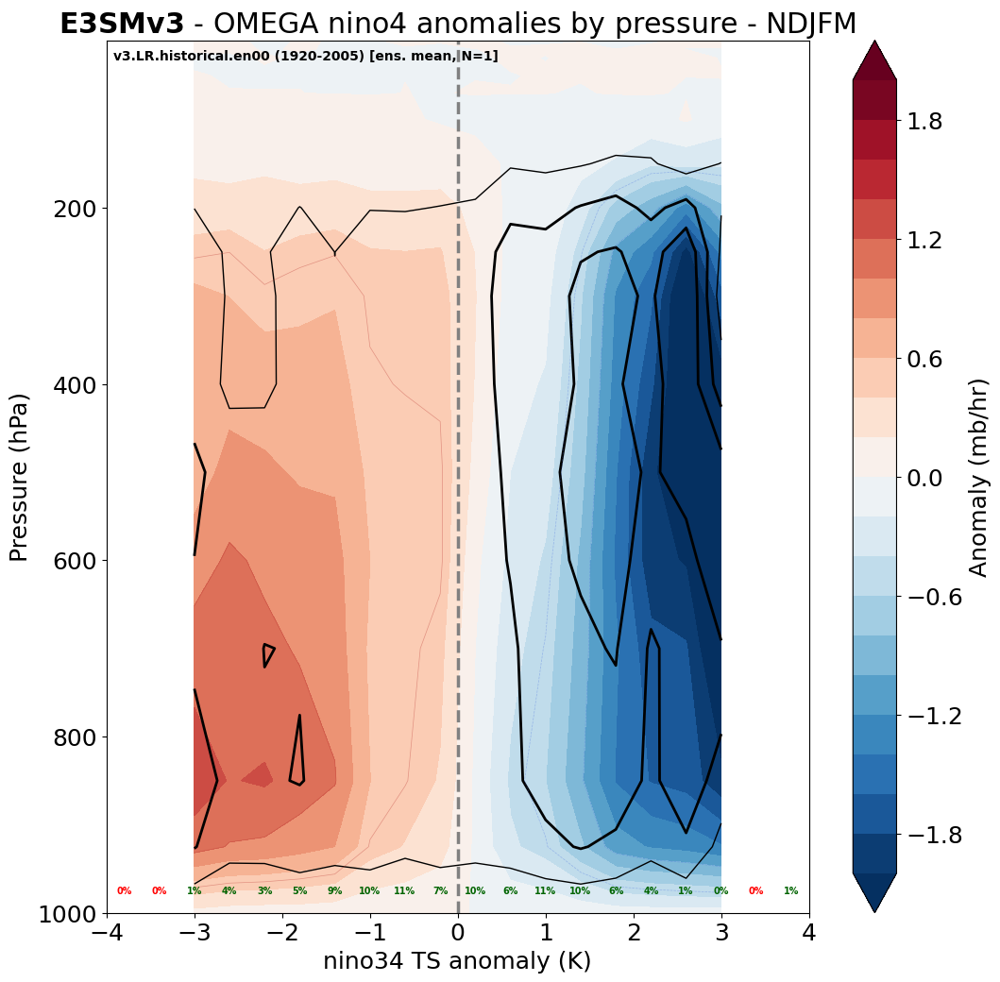


3D binned: CESM3
   - Cecile's Run
   - Found 1968 monthly hist files in /glade/derecho/scratch/hannay/archive/b.e30_alpha08b.BHISTC_LTso.ne30_t232_wgx3.315/atm/hist/
   - Using 1032 files for years 1920–2005
   - Using cached CESM3 dataset
-Interpolating  OMEGA  to  [100000.  92500.  85000.  70000.  60000.  50000.  40000.  30000.  25000.
  20000.  15000.  10000.   7000.   5000.   3000.   2000.]  mb
Done
  - Requested variable year range =  1920 - 2005
  - Time details for x-axis - TS
    - Available year range =  1920.Jan - 2005.Dec
  - Time details for y-axis - OMEGA
    - Available year range =  1920.Jan - 2005.Dec
    - DataArray time range of axes do not match
    - Common time range: 1920-01-01 – 2005-12-01  (430 steps)


/glade/work/rneale/conda-envs/neale_vproc2/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


  Ensemble: loading 2 members ...
    b.e30_alpha08b.BHISTC_LTso.ne30_t232_wgx3.315
   - Cecile's Run
   - Found 1968 monthly hist files in /glade/derecho/scratch/hannay/archive/b.e30_alpha08b.BHISTC_LTso.ne30_t232_wgx3.315/atm/hist/
   - Using 1032 files for years 1920–2005
   - Using cached CESM3 dataset
   - Cecile's Run
   - Found 1968 monthly hist files in /glade/derecho/scratch/hannay/archive/b.e30_alpha08b.BHISTC_LTso.ne30_t232_wgx3.315/atm/hist/
   - Using 1032 files for years 1920–2005
   - Using cached CESM3 dataset
-Interpolating  OMEGA  to  [100000.  92500.  85000.  70000.  60000.  50000.  40000.  30000.  25000.
  20000.  15000.  10000.   7000.   5000.   3000.   2000.]  mb
Done
  - Requested variable year range =  1920 - 2005
  - Time details for x-axis - TS
    - Available year range =  1920.Jan - 2005.Dec
  - Time details for y-axis - OMEGA
    - Available year range =  1920.Jan - 2005.Dec
    - DataArray time range of axes do not match
    - Common time range: 1920-01-01

/glade/work/rneale/conda-envs/neale_vproc2/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


    b.e30_alpha08b.BHISTC_LTso.ne30_t232_wgx3.316
   - Cecile's Run
   - Found 1968 monthly hist files in /glade/derecho/scratch/hannay/archive/b.e30_alpha08b.BHISTC_LTso.ne30_t232_wgx3.316/atm/hist/
   - Using 1032 files for years 1920–2005
   - Opened and cached CESM3 dataset
   - Cecile's Run
   - Found 1968 monthly hist files in /glade/derecho/scratch/hannay/archive/b.e30_alpha08b.BHISTC_LTso.ne30_t232_wgx3.316/atm/hist/
   - Using 1032 files for years 1920–2005
   - Using cached CESM3 dataset
-Interpolating  OMEGA  to  [100000.  92500.  85000.  70000.  60000.  50000.  40000.  30000.  25000.
  20000.  15000.  10000.   7000.   5000.   3000.   2000.]  mb
Done
  - Requested variable year range =  1920 - 2005
  - Time details for x-axis - TS
    - Available year range =  1920.Jan - 2005.Dec
  - Time details for y-axis - OMEGA
    - Available year range =  1920.Jan - 2005.Dec
    - DataArray time range of axes do not match
    - Common time range: 1920-01-01 – 2005-12-01  (430 steps)


/glade/work/rneale/conda-envs/neale_vproc2/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


  Ensemble: 2 members loaded


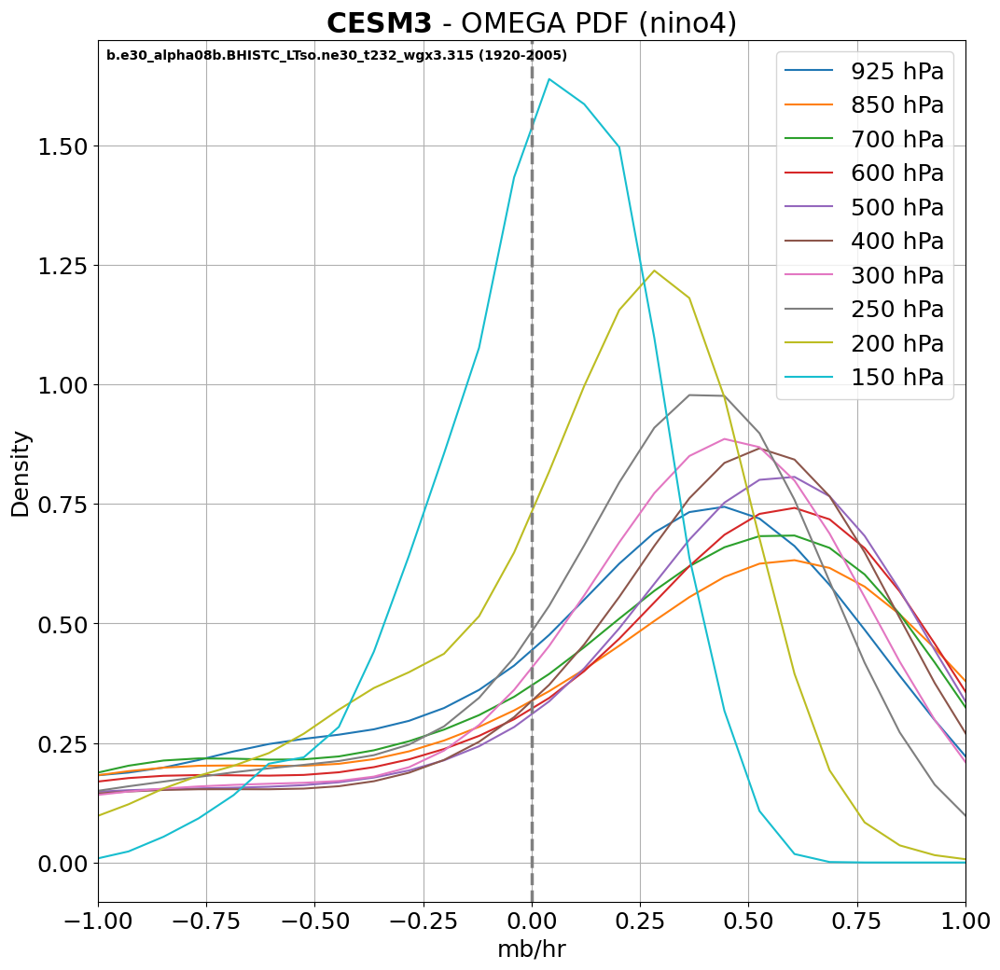

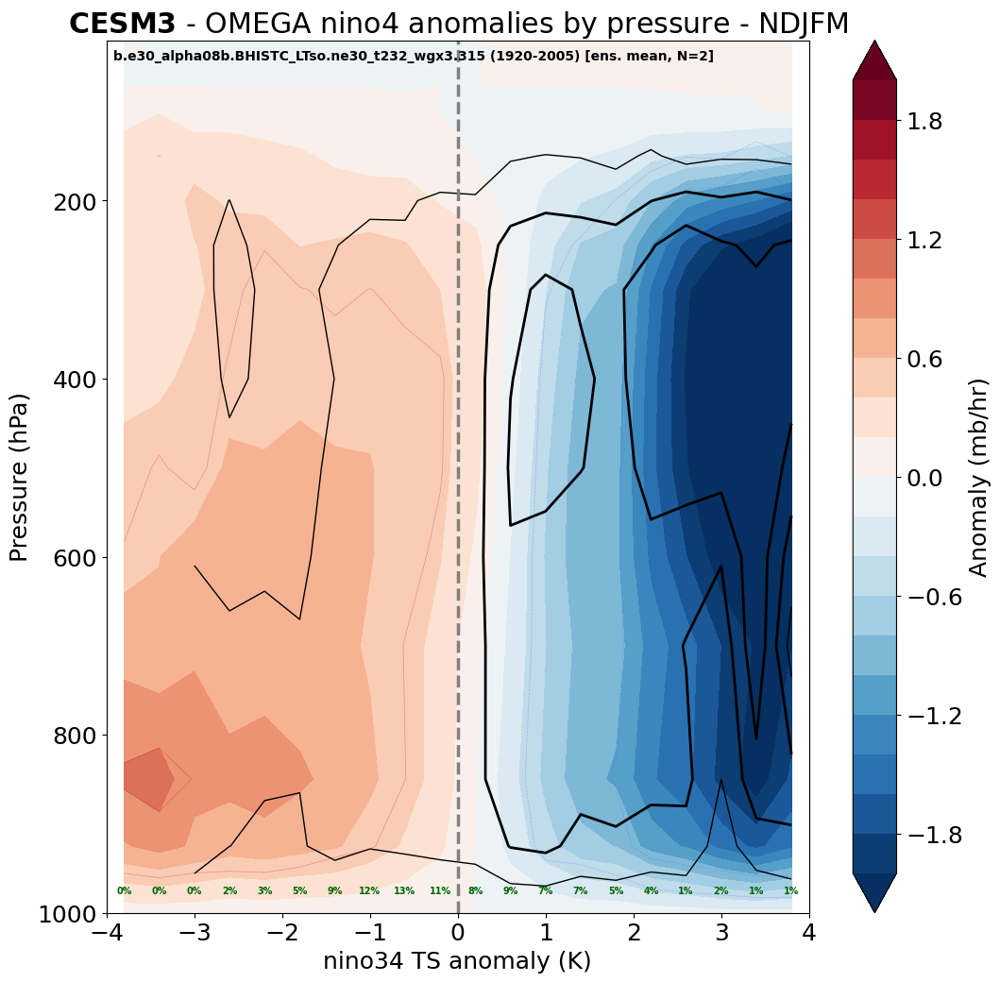

In [24]:
if DO_3D_PLOT:
    for d in cases_data:
        icase  = d['icase']
        fcname = d['fcname']
        ctype  = d['ctype']
        cnames = d['cnames']
        yr0    = d['yr0']
        yr1    = d['yr1']
        col    = d['color']
        da_x   = d['da_x']
        var_x_1d = d['var_x_1d']
        case_type = d['case_type']

        print(f'\n3D binned: {d["label"]}')

        fig_zp, ax_zp = plt.subplots(1, 1, figsize=(FIGXY, FIGXY))
        fig_zm, ax_zm = plt.subplots(1, 1, figsize=(FIGXY, FIGXY))

        da_y3d = mypy.get_dataset(cnames[-1], ctype, VAR_3D, yr0, yr1,
                                  READ_ALL_HIST, WRITE_TS_FILE, READ_TS_FILE)
        _, da_y3d = mypy.dataset_ts_trim(da_x, da_y3d, yr0, yr1, VAR_X, VAR_3D, GET_MONTHS)

        var_y_3d, var_y_pdf3d = mypy.nino_anom_ts(da_y3d, NINO_Y, Y_AVALS, kde_bw=KDE_BW_Y)

        # Per-level PDF plot
        plev_range = [100., 1000.]
        plev_plot  = (var_y_pdf3d.plev > plev_range[0]) & (var_y_pdf3d.plev < plev_range[1])
        for lev in var_y_pdf3d.plev.where(plev_plot, drop=True).values:
            ax_zp.plot(var_y_pdf3d.axis, var_y_pdf3d.sel(plev=lev), label=f'{int(lev)} hPa')
        ax_zp.set_title(r'$\bf{' + case_type + r'}$ - ' + VAR_3D + f' PDF ({NINO_Y})')
        ax_zp.set_xlabel(UNITS_3D)
        ax_zp.set_ylabel('Density')
        ax_zp.set_xlim(XLIM_PDF)
        ax_zp.grid(True)
        ax_zp.axvline(x=0., color='gray', linestyle='--', linewidth=2.5)
        ax_zp.legend()
        ax_zp.text(0.01, 0.99, f'{fcname} ({yr0}-{yr1})',
                   transform=ax_zp.transAxes, ha='left', va='top',
                   fontweight='bold', fontsize=10 * FSCALE)

        # Binned contour plot
        _x_aln, _y_aln = xr.align(var_x_1d, var_y_3d, join='inner')
        binned, binned_var, bin_counts = mypy.bin_mean_var_by_level(
            _y_aln, _x_aln, BIN_EDGES, BIN_CENTERS)

        # Ensemble members
        _n_mem      = N_MEMBERS[icase] if icase < len(N_MEMBERS) else 0
        _ens_kwargs = ENS_KWARGS[icase] if icase < len(ENS_KWARGS) else {}
        member_binned = []
        if _n_mem > 0 and ctype != 'OBS':
            print(f'  Ensemble: loading {_n_mem} members ...')
            _member_names = (list(CESM3_CASES) if ctype == 'cesm3' and CESM3_CASES
                             else mypy.make_ensemble_names(fcname, _n_mem, **_ens_kwargs))
            for _mcase in _member_names:
                print(f'    {_mcase}')
                try:
                    _da_x_m   = mypy.get_dataset(_mcase, ctype, VAR_X, yr0, yr1,
                                                 READ_ALL_HIST, False, READ_TS_FILE)
                    _da_y3d_m = mypy.get_dataset(_mcase, ctype, VAR_3D, yr0, yr1,
                                                 READ_ALL_HIST, WRITE_TS_FILE, READ_TS_FILE)
                    _da_x_m, _da_y3d_m = mypy.dataset_ts_trim(
                        _da_x_m, _da_y3d_m, yr0, yr1, VAR_X, VAR_3D, GET_MONTHS)
                    _var_x_1d_m, _ = mypy.nino_anom_ts(_da_x_m, NINO_X, X_AVALS, kde_bw=KDE_BW_X)
                    _var_y3d_m, _  = mypy.nino_anom_ts(_da_y3d_m, NINO_Y, Y_AVALS, kde_bw=KDE_BW_Y)
                    _xm, _ym       = xr.align(_var_x_1d_m, _var_y3d_m, join='inner')
                    _bm, _, _      = mypy.bin_mean_var_by_level(_ym, _xm, BIN_EDGES, BIN_CENTERS)
                    member_binned.append(_bm)
                except Exception as _e:
                    print(f'    Skipping {_mcase}: {_e}')
            if member_binned:
                print(f'  Ensemble: {len(member_binned)} members loaded')

        binned_plot = (xr.concat(member_binned, dim='member').mean('member')
                       if member_binned else binned)

        # Auto-set variability contour levels from first case
        if _slevels_ref is None:
            _vmax = float(np.nanpercentile(binned_var.values, 90))
            if _vmax > 0:
                _mag  = 10 ** np.floor(np.log10(_vmax / 4))
                _step = max(np.round(_vmax / (4 * _mag)) * _mag, _mag)
                _slevels_ref = np.arange(_step, _vmax * 1.05, _step)
            else:
                _slevels_ref = np.array([0.1, 0.2, 0.4, 1., 1.5, 2.])
            _swidths_ref = np.ones(len(_slevels_ref), dtype=int)
            _swidths_ref[len(_slevels_ref) // 2:] = 2

        dlev_p = (CRANGE_3D[1] - CRANGE_3D[0]) / N_BINS
        levels = np.arange(CRANGE_3D[0], CRANGE_3D[1] + dlev_p, dlev_p)

        cf = ax_zm.contourf(binned_plot.bin, binned_plot.plev, binned_plot,
                            levels=levels, cmap='RdBu_r', extend='both')
        plt.colorbar(cf, ax=ax_zm, label=f'Anomaly ({UNITS_3D})')
        ax_zm.contour(binned_plot.bin, binned_plot.plev, binned_var,
                      levels=_slevels_ref, linewidths=_swidths_ref, colors='black')

        if member_binned:
            _bm0 = member_binned[0]
            ax_zm.contour(_bm0.bin, _bm0.plev, _bm0,
                          levels=np.array([-1., -0.5, 0.5, 1.]),
                          colors=['royalblue', 'royalblue', 'firebrick', 'firebrick'],
                          linewidths=0.5, alpha=0.35, linestyles=['--', '--', '-', '-'])

        ax_zm.invert_yaxis()
        ax_zm.set_xlim([XMIN, XMAX])
        ax_zm.set_xlabel(f'{NINO_X} {VAR_X} anomaly ({UNITS_X})', usetex=False)
        ax_zm.set_ylabel('Pressure (hPa)')
        _ens_label = f' [ens. mean, N={len(member_binned)}]' if member_binned else ''
        ax_zm.text(0.01, 0.99, f'{fcname} ({yr0}-{yr1}){_ens_label}',
                   transform=ax_zm.transAxes, ha='left', va='top',
                   fontweight='bold', fontsize=10 * FSCALE)
        ax_zm.set_title(r'$\bf{' + case_type + r'}$ - ' + VAR_3D + ' ' + NINO_Y +
                        f' anomalies by pressure - {SEASON}', usetex=False)
        ax_zm.axvline(x=0., color='gray', linestyle='--', linewidth=2.5)

        _blended = mtransforms.blended_transform_factory(ax_zm.transData, ax_zm.transAxes)
        _total   = bin_counts.sum()
        for _bc, _cnt in zip(BIN_CENTERS, bin_counts):
            _pct = 100.0 * _cnt / _total if _total > 0 else 0.0
            ax_zm.text(_bc, 0.02, f'{_pct:.0f}%', transform=_blended,
                       ha='center', va='bottom', fontsize=7 * FSCALE,
                       color='red' if _cnt == 0 else 'darkgreen', fontweight='bold')

        _fstem = f'{fcname}_{VAR_X}_{VAR_3D}_{SEASON}_{NINO_X}_{NINO_Y}'
        fig_zp.savefig(fig_path(_fstem + '_plev_PDF_monthly'))
        fig_zm.savefig(fig_path(_fstem + '_plev_monthly'))
        plt.show()
        plt.close(fig_zp)
        plt.close(fig_zm)

        # Store binned results back into cases_data for the multi-case line plot
        d['binned']        = binned
        d['binned_var']    = binned_var
        d['bin_counts']    = bin_counts
        d['member_binned'] = member_binned

Mean Niño SST per case:
  ERA5        : 26.67 °C
  MERRA2      : 26.63 °C
  CESM2       : 26.78 °C
  CESM1       : 25.18 °C
  E3SMv2      : 25.72 °C
  E3SMv3      : 25.59 °C
  CESM3       : 24.97 °C


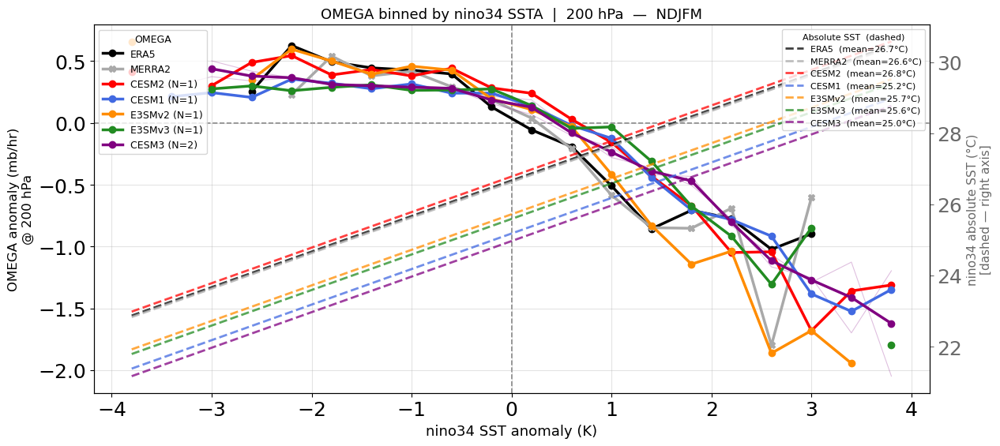

In [25]:
# Multi-case binned line plot — requires DO_3D_PLOT to have run
if DO_3D_PLOT:
    _binned_list = [d.get('member_binned') or d['binned'] for d in cases_data]
    _sst_means   = [d['sst_mean'] for d in cases_data]

    print('Mean Niño SST per case:')
    for d in cases_data:
        print(f'  {d["label"]:12s}: {d["sst_mean"] - 273.15:.2f} °C')

    fig_bl, ax_bl, ax_bl_r = mypy.plot_binned_line_sst_bias(
        binned_list    = _binned_list,
        bin_centers    = BIN_CENTERS,
        case_labels    = DISPLAY_NAMES,
        sst_clim_means = _sst_means,
        plev_sel       = BINNED_PLEV,
        plev_avg_range = BINNED_PLEV_RANGE,
        var_label      = VAR_3D,
        var_units      = UNITS_3D,
        xnino_reg      = NINO_X,
        season         = SEASON,
        colors         = COLORS,
        markers        = MARKERS,
    )

    _plev_str = str(int(BINNED_PLEV)) if BINNED_PLEV is not None else 'vmean'
    fig_bl.savefig(fig_path(f'{VAR_3D}{_plev_str}_{SEASON}_{NINO_X}_binned_line'),
                   dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig_bl)

---
## 2D Lat-Lon Composites


Lat-lon composites: ERA5
  - Grabbing  ERA5  data for Z3
  - Requested variable year range =  1980 - 2023
  - Time details for x-axis - TS
    - Available year range =  1980.Jan - 2023.Dec
  - Time details for y-axis - Z3
    - Available year range =  1940.Jan - 2023.Dec
    - DataArray time range of axes do not match
    - Common time range: 1980-01-01 – 2023-12-01  (220 steps)


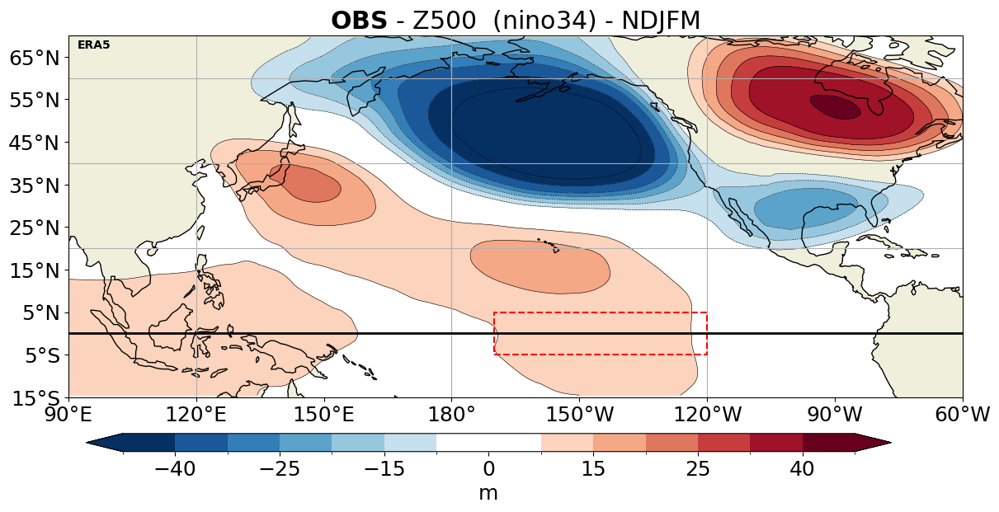

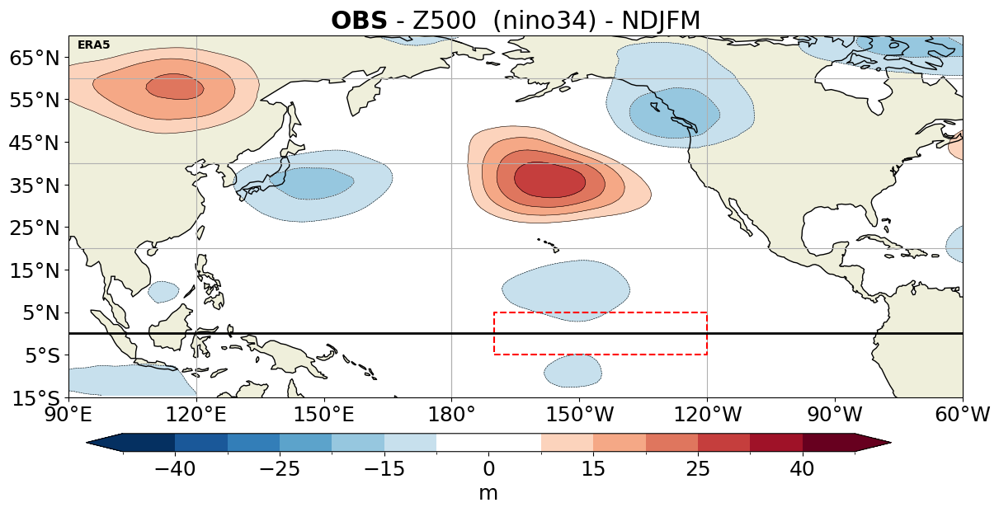


Lat-lon composites: MERRA2
  - Grabbing  MERRA2  data for Z3
  - Requested variable year range =  1980 - 2023
  - Time details for x-axis - TS
    - Available year range =  1980.Jan - 2023.Dec
  - Time details for y-axis - Z3
    - Available year range =  1980.Jan - 2023.Dec
    - DataArray time range of axes do not match
    - Common time range: 1980-01-01 – 2023-12-01  (220 steps)


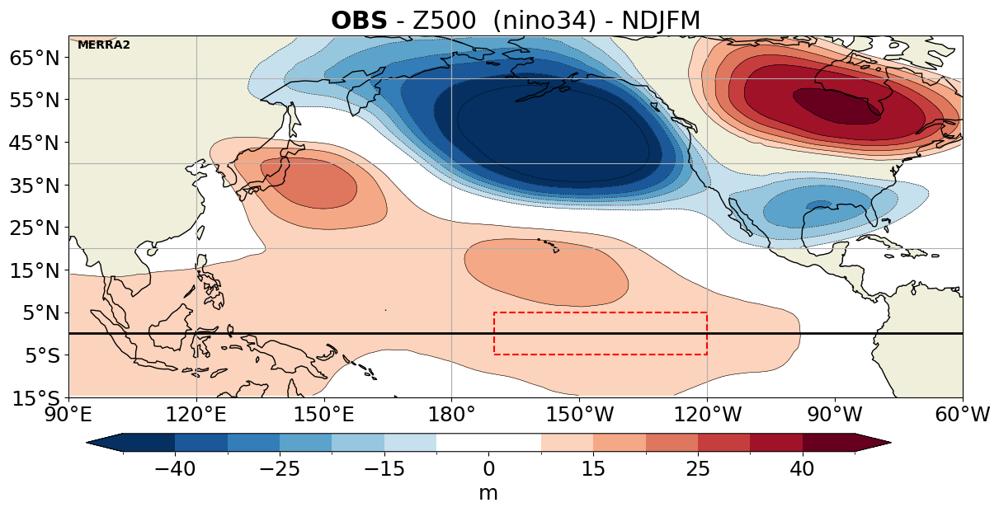

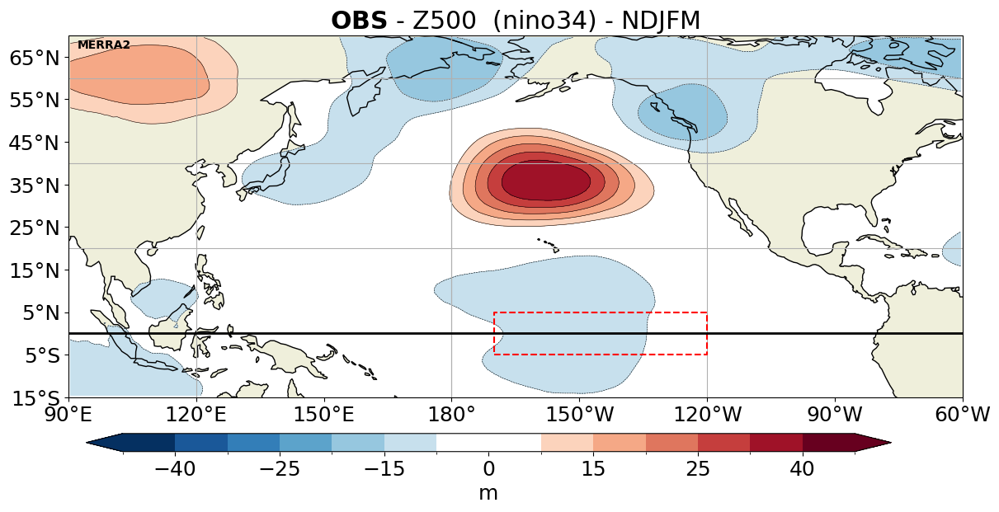


Lat-lon composites: CESM2
  - Grabbing file(s) for CESM2
-Interpolating  Z3  to  [100000.  92500.  85000.  70000.  60000.  50000.  40000.  30000.  25000.
  20000.  15000.  10000.   7000.   5000.   3000.   2000.]  mb
Done
  - Requested variable year range =  1920 - 2005
  - Time details for x-axis - TS
    - Available year range =  1920.Jan - 2005.Dec
  - Time details for y-axis - Z3
    - Available year range =  1850.Feb - 2015.Jan
    - DataArray time range of axes do not match
    - Common time range: 1920-01-01 – 2005-12-01  (430 steps)


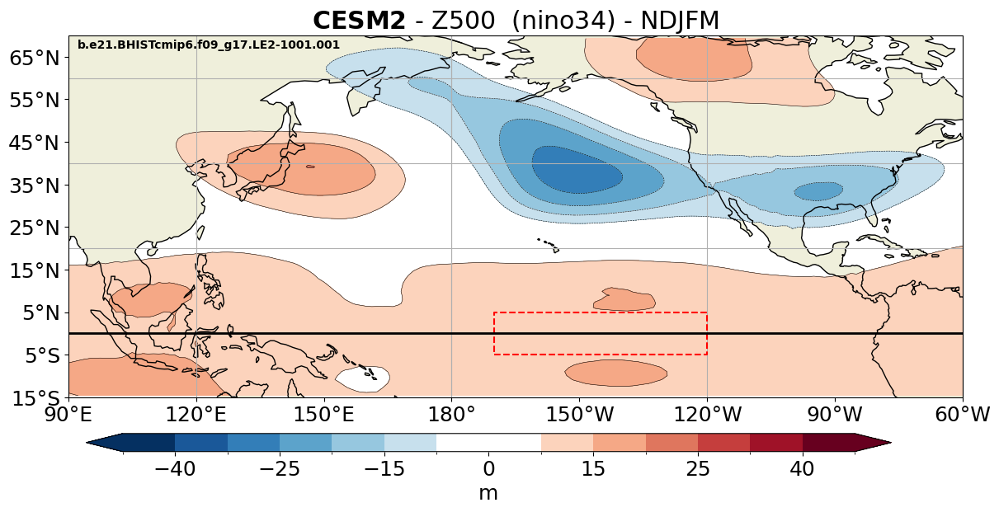

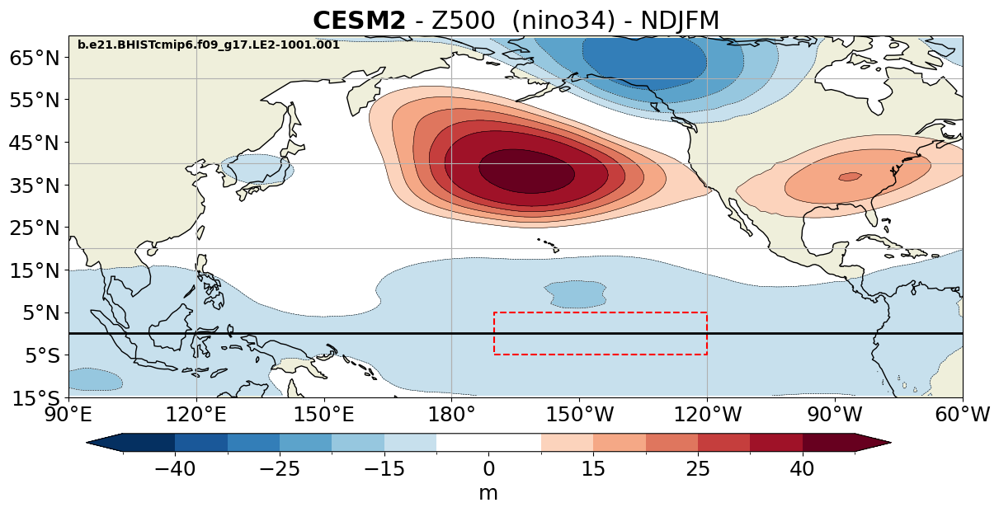


Lat-lon composites: CESM1
  - Grabbing file(s) for CESM1
-Interpolating  Z3  to  [100000.  92500.  85000.  70000.  60000.  50000.  40000.  30000.  25000.
  20000.  15000.  10000.   7000.   5000.   3000.   2000.]  mb
Done
  - Requested variable year range =  1920 - 2005
  - Time details for x-axis - TS
    - Available year range =  1920.Jan - 2005.Dec
  - Time details for y-axis - Z3
    - Available year range =  1850.Feb - 2006.Jan
    - DataArray time range of axes do not match
    - Common time range: 1920-01-01 – 2005-12-01  (430 steps)


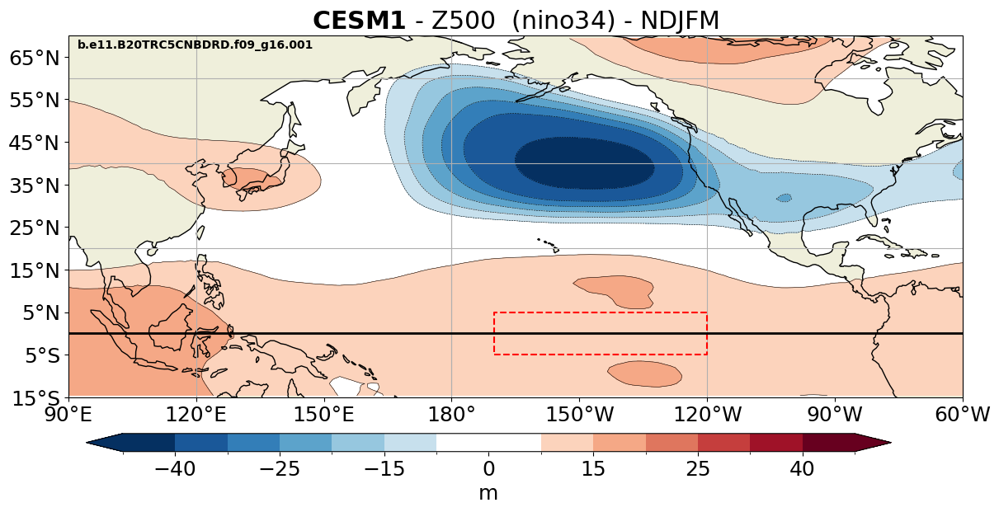

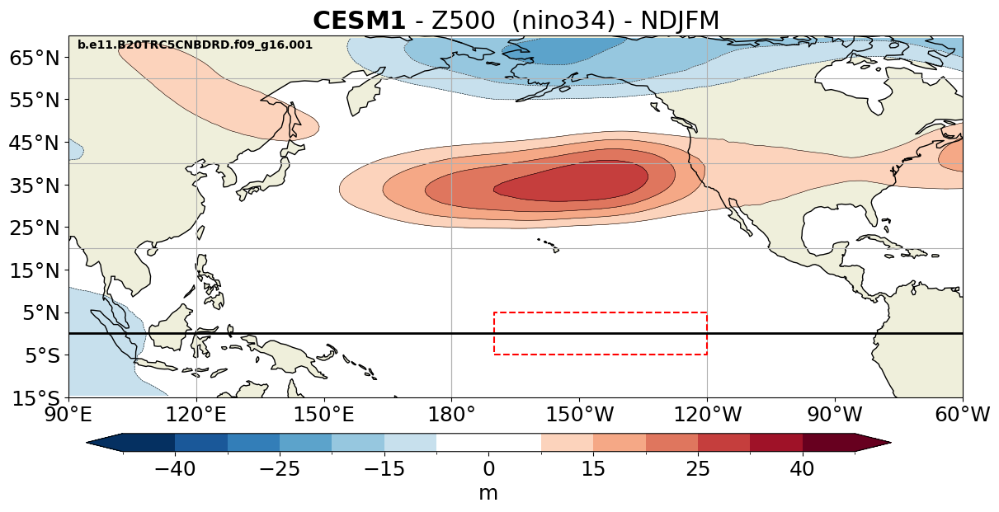


Lat-lon composites: E3SMv2
  - Grabbing E3SM file(s) for Z3
-Interpolating  Z3  to  [100000.  92500.  85000.  70000.  60000.  50000.  40000.  30000.  25000.
  20000.  15000.  10000.   7000.   5000.   3000.   2000.]  mb
Done
  - Requested variable year range =  1920 - 2005
  - Time details for x-axis - TS
    - Available year range =  1920.Jan - 2005.Dec
  - Time details for y-axis - Z3
    - Available year range =  1850.Feb - 2015.Jan
    - DataArray time range of axes do not match
    - Common time range: 1920-01-01 – 2005-12-01  (430 steps)


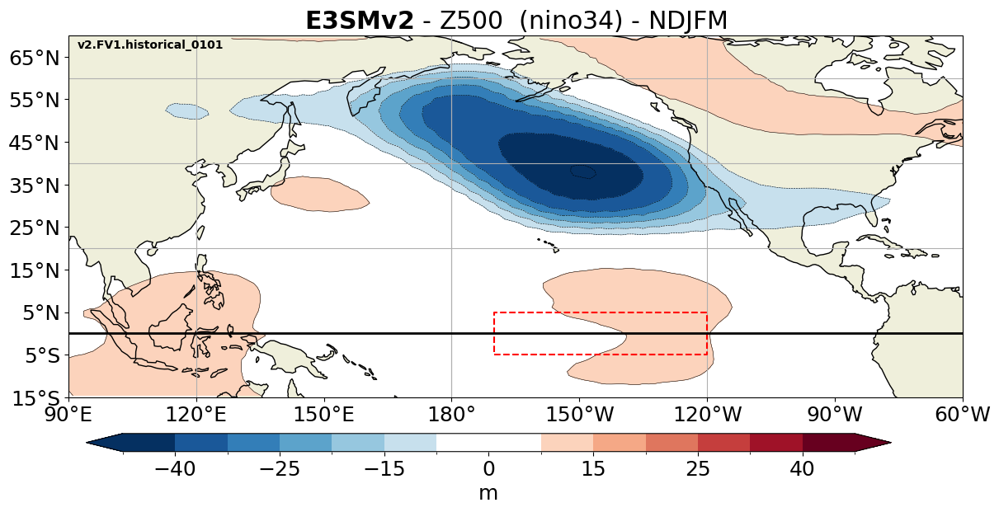

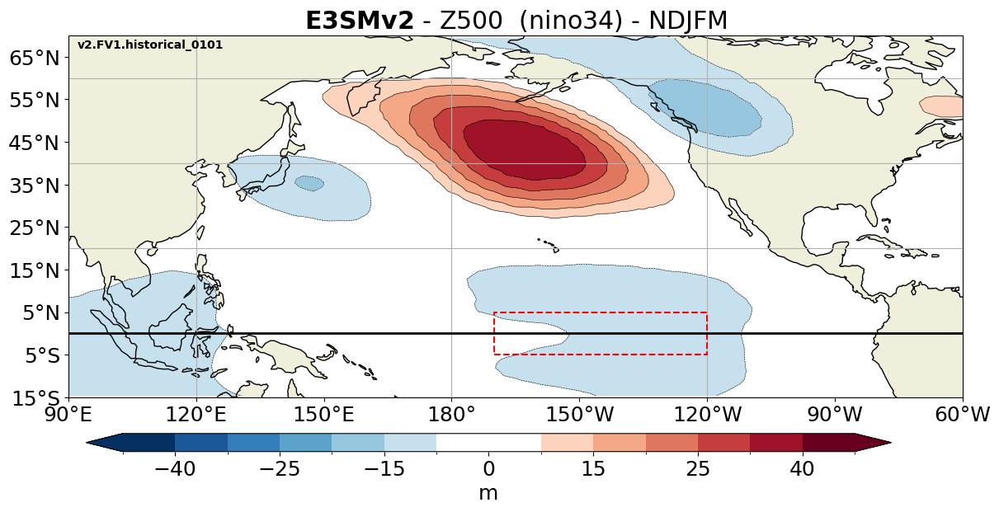


Lat-lon composites: E3SMv3
  - Grabbing E3SMv3 file(s) for Z3
  - Requested variable year range =  1920 - 2005
  - Time details for x-axis - TS
    - Available year range =  1920.Jan - 2005.Dec
  - Time details for y-axis - Z3
    - Available year range =  1850.Feb - 2051.Jan
    - DataArray time range of axes do not match
    - Common time range: 1920-01-01 – 2005-12-01  (430 steps)


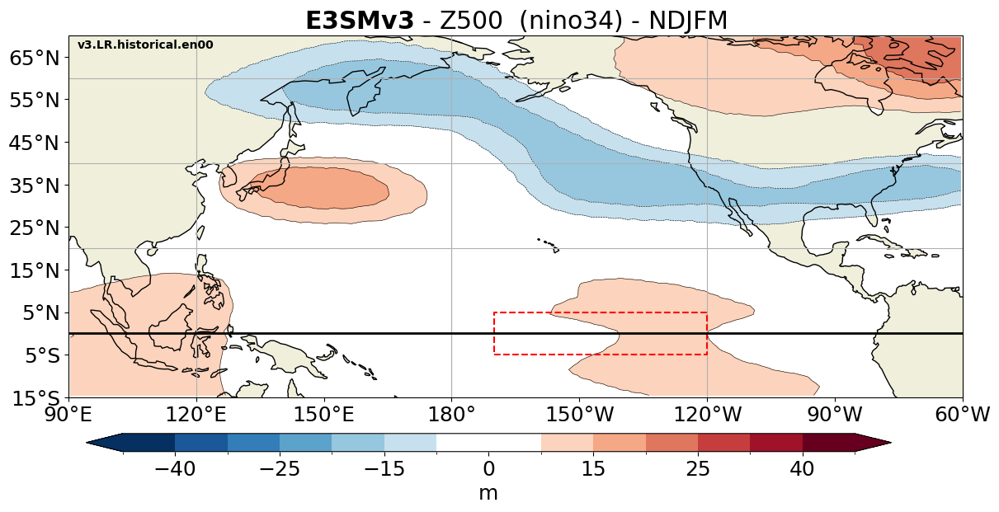

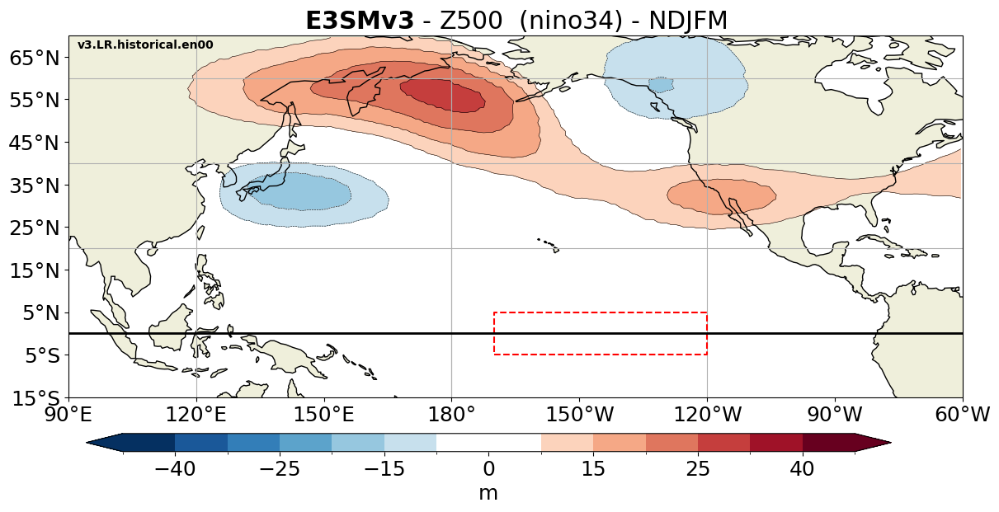


Lat-lon composites: CESM3
   - Cecile's Run
   - Found 1968 monthly hist files in /glade/derecho/scratch/hannay/archive/b.e30_alpha08b.BHISTC_LTso.ne30_t232_wgx3.315/atm/hist/
   - Using 1032 files for years 1920–2005
   - Using cached CESM3 dataset
-Interpolating  Z3  to  [100000.  92500.  85000.  70000.  60000.  50000.  40000.  30000.  25000.
  20000.  15000.  10000.   7000.   5000.   3000.   2000.]  mb
Done
  - Requested variable year range =  1920 - 2005
  - Time details for x-axis - TS
    - Available year range =  1920.Jan - 2005.Dec
  - Time details for y-axis - Z3
    - Available year range =  1920.Jan - 2005.Dec
    - DataArray time range of axes do not match
    - Common time range: 1920-01-01 – 2005-12-01  (430 steps)


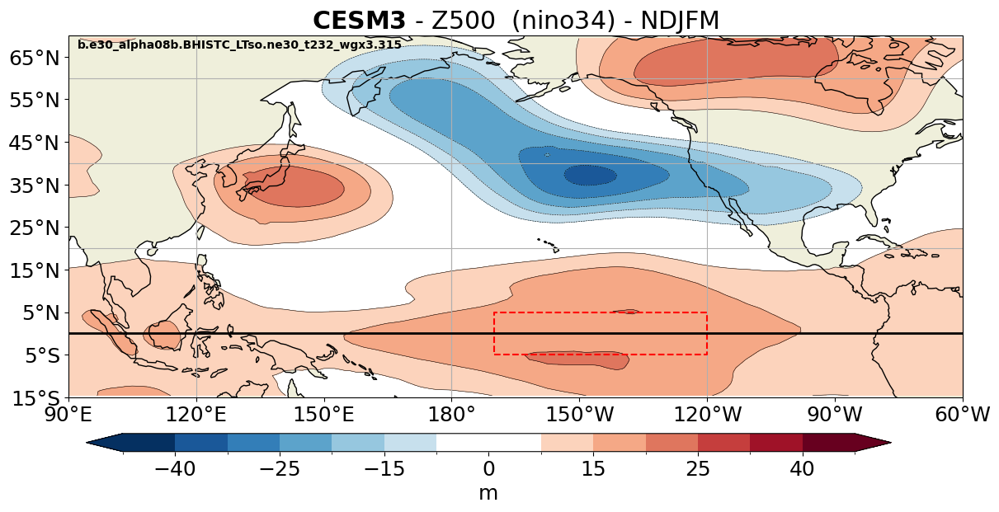

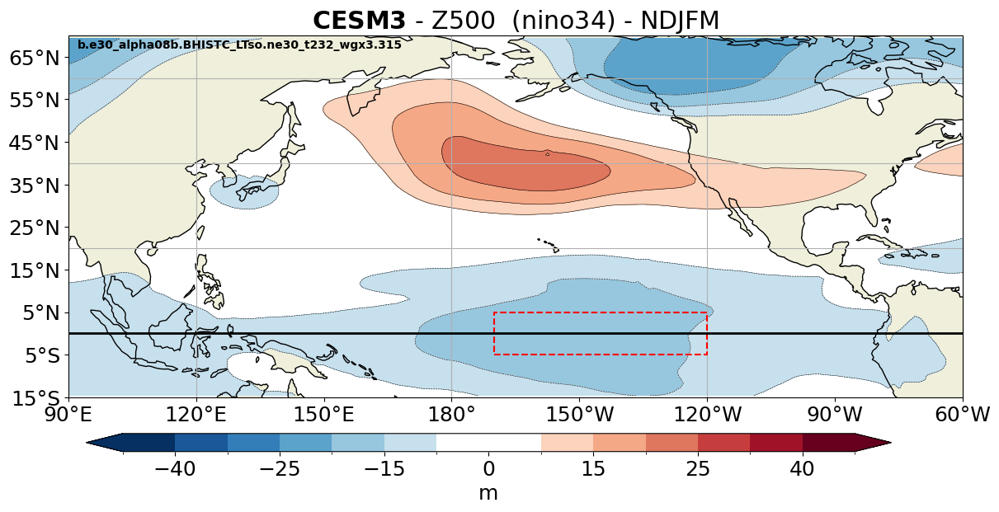

In [26]:
if DO_LATLON:
    for d in cases_data:
        icase     = d['icase']
        fcname    = d['fcname']
        ctype     = d['ctype']
        cnames    = d['cnames']
        case_type = d['case_type']
        yr0       = d['yr0']
        yr1       = d['yr1']
        da_x      = d['da_x']
        var_x_1d  = d['var_x_1d']

        print(f'\nLat-lon composites: {d["label"]}')

        da_y3d = mypy.get_dataset(cnames[-1], ctype, VAR_LATLON, yr0, yr1,
                                  READ_ALL_HIST, WRITE_TS_FILE, READ_TS_FILE)
        plot_latlon_da = da_y3d.sel(plev=PLEV_LATLON, method='nearest').squeeze(drop=True)
        _, plot_latlon_da = mypy.dataset_ts_trim(
            da_x, plot_latlon_da, yr0, yr1, VAR_X, VAR_LATLON, GET_MONTHS)

        plot_latlon_da, _var_x_ll = xr.align(plot_latlon_da, var_x_1d)
        plot_anom = mypy.monthly_anom(plot_latlon_da)

        nino_mask = _var_x_ll >= 1.0
        nina_mask = _var_x_ll <= -1.0

        for comp_label, comp_mask, fig_suffix in [
                ('El Niño', nino_mask, 'nino'), ('La Niña', nina_mask, 'nina')]:
            comp_da = plot_anom.sel(time=comp_mask).mean('time')
            fig_ll, ax_ll = plt.subplots(
                1, 1, figsize=(FIGXY, FIGXY),
                subplot_kw={'projection': CCRS_PREG}, constrained_layout=True)
            mypy.plot_latlon(ax_ll, fig_ll, icase, VAR_LATLON_2D, comp_da, UNITS_LL,
                             case_type, fcname, SEASON, PREGION, NINO_X,
                             False, False, False, FSCALE,
                             equator_line=True, transparent_zero=True)
            _fstem = f'{fcname}_{VAR_X}_{VAR_LATLON_2D}_{SEASON}_{NINO_X}_{NINO_Y}_latlon_{fig_suffix}_monthly'
            fig_ll.savefig(fig_path(_fstem))
            plt.show()
            plt.close(fig_ll)

In [27]:
if DO_RWS:
    RWS_PLEV = 200

    for d in cases_data:
        icase     = d['icase']
        fcname    = d['fcname']
        ctype     = d['ctype']
        cnames    = d['cnames']
        case_type = d['case_type']
        yr0       = d['yr0']
        yr1       = d['yr1']
        da_x      = d['da_x']
        var_x_1d  = d['var_x_1d']

        print(f'\nRWS composites: {d["label"]}')

        da_u = mypy.get_dataset(cnames[-1], ctype, 'U', yr0, yr1,
                                READ_ALL_HIST, WRITE_TS_FILE, READ_TS_FILE)
        da_v = mypy.get_dataset(cnames[-1], ctype, 'V', yr0, yr1,
                                READ_ALL_HIST, WRITE_TS_FILE, READ_TS_FILE)
        da_u = da_u.sel(plev=RWS_PLEV, method='nearest').squeeze()
        da_v = da_v.sel(plev=RWS_PLEV, method='nearest').squeeze()
        _, da_u = mypy.dataset_ts_trim(da_x, da_u, yr0, yr1, VAR_X, 'U', GET_MONTHS)
        _, da_v = mypy.dataset_ts_trim(da_x, da_v, yr0, yr1, VAR_X, 'V', GET_MONTHS)

        da_rws      = mypy.calc_rws(da_u, da_v).compute()
        da_rws_anom = mypy.monthly_anom(da_rws)
        da_rws_anom, var_x_rws = xr.align(da_rws_anom, var_x_1d)

        nino_mask = var_x_rws >= 1.0
        nina_mask = var_x_rws <= -1.0
        rws_nino  = da_rws_anom.sel(time=nino_mask).mean('time') * 1e11
        rws_nina  = da_rws_anom.sel(time=nina_mask).mean('time') * 1e11

        if RWS_SMOOTH_SIGMA > 0:
            for rws_da in [rws_nino, rws_nina]:
                rws_da[:] = gaussian_filter(rws_da.values, sigma=RWS_SMOOTH_SIGMA)
            rws_nino = xr.DataArray(gaussian_filter(rws_nino.values, sigma=RWS_SMOOTH_SIGMA),
                                    coords=rws_nino.coords, dims=rws_nino.dims)
            rws_nina = xr.DataArray(gaussian_filter(rws_nina.values, sigma=RWS_SMOOTH_SIGMA),
                                    coords=rws_nina.coords, dims=rws_nina.dims)

        rws_levels = np.array([-10., -8., -6., -4., -2., -1., 0., 1., 2., 4., 6., 8., 10.])
        _rws_units = r'$\times10^{-11}$ s$^{-2}$'

        for rws_comp, comp_sfx in [(rws_nino, 'nino'), (rws_nina, 'nina')]:
            fig_rws, ax_rws = plt.subplots(
                1, 1, figsize=(FIGXY, FIGXY),
                subplot_kw={'projection': CCRS_PREG}, constrained_layout=True)
            mypy.plot_latlon(ax_rws, fig_rws, icase, f'RWS{RWS_PLEV}', rws_comp,
                             _rws_units, case_type, fcname, SEASON, PREGION, NINO_X,
                             False, False, False, FSCALE,
                             levels=rws_levels, mask_thresh=0.05)
            _fstem = f'{fcname}_RWS{RWS_PLEV}_{SEASON}_{NINO_X}_{comp_sfx}_latlon'
            fig_rws.savefig(fig_path(_fstem))
            plt.show()
            plt.close(fig_rws)

In [28]:
if DO_DIVWIND:
    TD_PLEV = 200

    for d in cases_data:
        icase     = d['icase']
        fcname    = d['fcname']
        ctype     = d['ctype']
        cnames    = d['cnames']
        case_type = d['case_type']
        yr0       = d['yr0']
        yr1       = d['yr1']
        da_x      = d['da_x']
        var_x_1d  = d['var_x_1d']

        print(f'\nPRECT/chi-wind/DIV composites: {d["label"]}')

        da_u = mypy.get_dataset(cnames[-1], ctype, 'U', yr0, yr1,
                                READ_ALL_HIST, WRITE_TS_FILE, READ_TS_FILE)
        da_v = mypy.get_dataset(cnames[-1], ctype, 'V', yr0, yr1,
                                READ_ALL_HIST, WRITE_TS_FILE, READ_TS_FILE)
        da_u = da_u.sel(plev=TD_PLEV, method='nearest').squeeze()
        da_v = da_v.sel(plev=TD_PLEV, method='nearest').squeeze()
        _, da_u = mypy.dataset_ts_trim(da_x, da_u, yr0, yr1, VAR_X, 'U', GET_MONTHS)
        _, da_v = mypy.dataset_ts_trim(da_x, da_v, yr0, yr1, VAR_X, 'V', GET_MONTHS)

        da_prect = mypy.get_dataset(cnames[-1], ctype, 'PRECT', yr0, yr1,
                                    READ_ALL_HIST, WRITE_TS_FILE, READ_TS_FILE)
        _, da_prect = mypy.dataset_ts_trim(da_x, da_prect, yr0, yr1, VAR_X, 'PRECT', GET_MONTHS)

        u_anom     = mypy.monthly_anom(da_u)
        v_anom     = mypy.monthly_anom(da_v)
        prect_anom = mypy.monthly_anom(da_prect)

        u_anom,     var_x_td = xr.align(u_anom,     var_x_1d)
        v_anom,     _        = xr.align(v_anom,      var_x_td)
        prect_anom, _        = xr.align(prect_anom,  var_x_td)

        nino_mask = var_x_td >= 1.0
        nina_mask = var_x_td <= -1.0

        preg_area  = mypy.get_pregion(PREGION)
        td_lat_min = preg_area['lat_min']; td_lat_max = preg_area['lat_max']
        td_lon_min = preg_area['lon_min']; td_lon_max = preg_area['lon_max']
        dpproj = ccrs.PlateCarree()

        def _regional(da):
            return da.sortby('lat').sel(
                lat=slice(td_lat_min, td_lat_max), lon=slice(td_lon_min, td_lon_max))

        for comp_label, comp_mask in [('nino', nino_mask), ('nina', nina_mask)]:
            prect_comp = prect_anom.sel(time=comp_mask).mean('time')
            u_comp     = u_anom.sel(time=comp_mask).mean('time').compute()
            v_comp     = v_anom.sel(time=comp_mask).mean('time').compute()

            if DIV_SMOOTH_SIGMA > 0:
                u_comp = xr.DataArray(gaussian_filter(u_comp.values, sigma=DIV_SMOOTH_SIGMA),
                                      coords=u_comp.coords, dims=u_comp.dims)
                v_comp = xr.DataArray(gaussian_filter(v_comp.values, sigma=DIV_SMOOTH_SIGMA),
                                      coords=v_comp.coords, dims=v_comp.dims)

            u_chi_comp, v_chi_comp, div_comp = mypy.calc_div_wind(u_comp, v_comp)
            div_comp = div_comp * 1e6

            prect_plot = _regional(prect_comp)
            u_chi_plot = _regional(u_chi_comp)
            v_chi_plot = _regional(v_chi_comp)
            div_plot   = _regional(div_comp)

            fig_td, ax_td = plt.subplots(
                1, 1, figsize=(FIGXY, FIGXY),
                subplot_kw={'projection': CCRS_PREG}, constrained_layout=True)

            prect_lev = np.linspace(-5., 5., 21)
            cf_pr = ax_td.contourf(prect_plot.lon, prect_plot.lat, prect_plot,
                                   levels=prect_lev, cmap='BrBG', extend='both',
                                   transform=dpproj)
            cbar_pr = fig_td.colorbar(cf_pr, ax=ax_td, orientation='horizontal',
                                      fraction=0.05, pad=0.08)
            cbar_pr.set_label('PRECT anomaly (mm/day)', fontsize=12 * FSCALE)

            ax_td.contour(div_plot.lon, div_plot.lat, div_plot,
                          levels=np.array([0.5, 1., 2., 3.]), colors='black',
                          linewidths=1.5, linestyles='solid', transform=dpproj)
            ax_td.contour(div_plot.lon, div_plot.lat, div_plot,
                          levels=np.array([-3., -2., -1., -0.5]), colors='black',
                          linewidths=1.0, linestyles='dashed', transform=dpproj)

            qskip  = max(1, len(u_chi_plot.lat) // 15)
            lon2d, lat2d = np.meshgrid(u_chi_plot.lon.values[::qskip],
                                       u_chi_plot.lat.values[::qskip])
            u_q = u_chi_plot.transpose('lat', 'lon').values[::qskip, ::qskip]
            v_q = v_chi_plot.transpose('lat', 'lon').values[::qskip, ::qskip]
            qv  = ax_td.quiver(lon2d, lat2d, u_q, v_q, transform=dpproj,
                               scale=20., width=0.003, color='dimgray', alpha=0.85)
            ax_td.quiverkey(qv, X=0.88, Y=1.03, U=2., label='2 m/s', labelpos='E',
                            fontproperties={'size': 10 * FSCALE})

            ax_td.coastlines(linewidth=1, color='black', resolution='110m')
            ax_td.gridlines()
            ax_td.add_feature(cfeature.LAND, facecolor='silver', zorder=0)

            if PREGION != 'Global':
                ax_td.set_yticks(np.arange(td_lat_min, td_lat_max + 10., 10.), crs=dpproj)
                ax_td.yaxis.set_major_formatter(LatitudeFormatter())
                ax_td.set_xticks(np.arange(td_lon_min, td_lon_max + 30., 30.), crs=dpproj)
                ax_td.xaxis.set_major_formatter(LongitudeFormatter())

            _nw, _ne, _nn, _ns = mypy.nino_region(NINO_X)
            ax_td.plot([_nw, _ne, _ne, _nw, _nw], [_ns, _ns, _nn, _nn, _ns],
                       transform=dpproj, color='red', linewidth=1.5, linestyle='--', zorder=6)

            lbl_title = 'El Niño' if comp_label == 'nino' else 'La Niña'
            ax_td.set_title(r'$\bf{' + case_type + r'}$ - PRECT / χ-wind / DIV' +
                            str(TD_PLEV) + f' ({NINO_X}) {lbl_title} - {SEASON}')
            ax_td.text(0.01, 0.99, f'{fcname} ({yr0}-{yr1})',
                       transform=ax_td.transAxes, ha='left', va='top',
                       fontweight='bold', fontsize=10 * FSCALE)

            _fstem = f'{fcname}_comp_PRECT_chiwind_DIV{TD_PLEV}_{SEASON}_{NINO_X}_{comp_label}_latlon'
            fig_td.savefig(fig_path(_fstem))
            plt.show()
            plt.close(fig_td)

---
## Z500 Analysis

In [29]:
if DO_Z500_SCATTER:
    # ── Collect per-case Z500 seasonal scatter data ──────────────────────────────────
    collected_z500 = []
    _preg_z500 = mypy.get_pregion(Z500_REGION)

    for d in cases_data:
        fcname   = d['fcname']
        ctype    = d['ctype']
        cnames   = d['cnames']
        yr0      = d['yr0']
        yr1      = d['yr1']
        da_x     = d['da_x']
        var_x_1d = d['var_x_1d']

        print(f'\nZ500 scatter: {d["label"]}')

        da_z500 = mypy.get_dataset(cnames[-1], ctype, 'Z3', yr0, yr1,
                                   READ_ALL_HIST, WRITE_TS_FILE, READ_TS_FILE)
        da_z500 = da_z500.sel(plev=500, method='nearest').squeeze(drop=True)
        _, da_z500 = mypy.dataset_ts_trim(da_x, da_z500, yr0, yr1, VAR_X, 'Z3', GET_MONTHS)
        da_z500, _var_x_z500 = xr.align(da_z500, var_x_1d)

        da_z500_reg = mypy.monthly_anom(da_z500).sortby('lat').sel(
            lat=slice(_preg_z500['lat_min'], _preg_z500['lat_max']),
            lon=slice(_preg_z500['lon_min'], _preg_z500['lon_max'])
        ).compute()

        z500_info = mypy.calc_z500_seasonal_scatter(da_z500_reg, _var_x_z500)
        print(f'  EOF PC1 var. explained: {z500_info["var_exp"]:.1f}%')
        print(f'  Seasons collected: {len(z500_info["ssta_seas"])}')

        collected_z500.append({
            **z500_info,
            'label':  d['label'],
            'color':  d['color'],
            'marker': d['marker'],
            'yr0':    yr0,
            'yr1':    yr1,
        })

    # ── Spatial max / min scatter plot ──────────────────────────────────────────────
    fig_zsc, ax_zsc = plt.subplots(1, 1, figsize=(13, 8), constrained_layout=True)

    for dz in collected_z500:
        lbl = f'{dz["label"]} ({dz["yr0"]}-{dz["yr1"]})'
        col = dz['color']
        mrk = dz['marker']

        ax_zsc.scatter(dz['ssta_seas'], dz['z500_tmax'], color=col, alpha=0.35, s=20,
                       marker=mrk, label=lbl)
        ax_zsc.scatter(dz['ssta_seas'], dz['z500_tmin'], color=col, alpha=0.35, s=20,
                       marker=mrk, label='_nolegend_')

        for z500_pts, ls in [(dz['z500_tmax'], '-'), (dz['z500_tmin'], '--')]:
            sort_idx = np.argsort(dz['ssta_seas'])
            xs       = dz['ssta_seas'][sort_idx]
            ys       = z500_pts[sort_idx]
            spl      = UnivariateSpline(xs, ys, k=3, s=len(xs) * np.var(ys) * 2)
            x_fine   = np.linspace(xs[0], xs[-1], 300)
            ax_zsc.plot(x_fine, spl(x_fine), color=col, linewidth=2.5,
                        linestyle=ls, zorder=5, label='_nolegend_')

    ax_zsc.axhline(0., color='gray', linestyle='--', linewidth=1.2)
    ax_zsc.axvline(0., color='gray', linestyle='--', linewidth=1.2)
    ax_zsc.set_xlabel(f'{NINO_X} SST anomaly (K)', fontsize=13)
    ax_zsc.set_ylabel(f'Z500 anomaly in {Z500_REGION} (m)', fontsize=13)
    ax_zsc.set_title(f'Z500 seasonal mean anomaly range vs {NINO_X} SSTA — {SEASON}', fontsize=13)
    ax_zsc.legend(loc='upper left', fontsize=9, framealpha=0.8,
                  title='— max   -- min', title_fontsize=8)
    ax_zsc.grid(True, alpha=0.35)

    fig_zsc.savefig(fig_path(f'Z500_maxmin_scatter_{SEASON}_{NINO_X}'),
                    dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig_zsc)

    # ── EOF PC1 scatter plot ───────────────────────────────────────────────────────
    fig_eof, ax_eof = plt.subplots(1, 1, figsize=(13, 8), constrained_layout=True)

    for dz in collected_z500:
        col = dz['color']
        mrk = dz['marker']
        lbl = f'{dz["label"]} ({dz["yr0"]}-{dz["yr1"]})  VE={dz["var_exp"]:.0f}%'

        ax_eof.scatter(dz['ssta_seas'], dz['pc1'], color=col, alpha=0.4, s=25,
                       marker=mrk, label=lbl)

        sort_idx = np.argsort(dz['ssta_seas'])
        xs       = dz['ssta_seas'][sort_idx]
        ys       = dz['pc1'][sort_idx]
        spl      = UnivariateSpline(xs, ys, k=3, s=len(xs) * np.var(ys) * 2)
        x_fine   = np.linspace(xs[0], xs[-1], 300)
        ax_eof.plot(x_fine, spl(x_fine), color=col, linewidth=2.5, zorder=5)

    ax_eof.axhline(0., color='gray', linestyle='--', linewidth=1.2)
    ax_eof.axvline(0., color='gray', linestyle='--', linewidth=1.2)
    ax_eof.set_xlabel(f'{NINO_X} SST anomaly (K)', fontsize=13)
    ax_eof.set_ylabel(f'Z500 EOF1 PC score in {Z500_REGION}', fontsize=13)
    ax_eof.set_title(
        f'Z500 leading EOF PC1 vs {NINO_X} SSTA — {SEASON}\n'
        f'(region: {Z500_REGION};  sign: PC1>0 = El Niño-like)',
        fontsize=13)
    ax_eof.legend(loc='upper left', fontsize=9, framealpha=0.8,
                  title='VE = var. exp. EOF1', title_fontsize=8)
    ax_eof.grid(True, alpha=0.35)

    fig_eof.savefig(fig_path(f'Z500_EOF1_scatter_{SEASON}_{NINO_X}'),
                    dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig_eof)